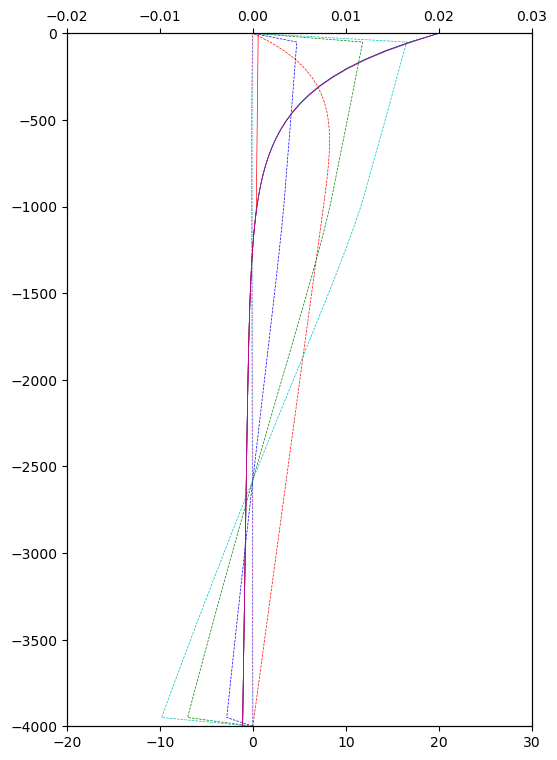

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/2562970485.py:438: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/2562970485.py:512: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


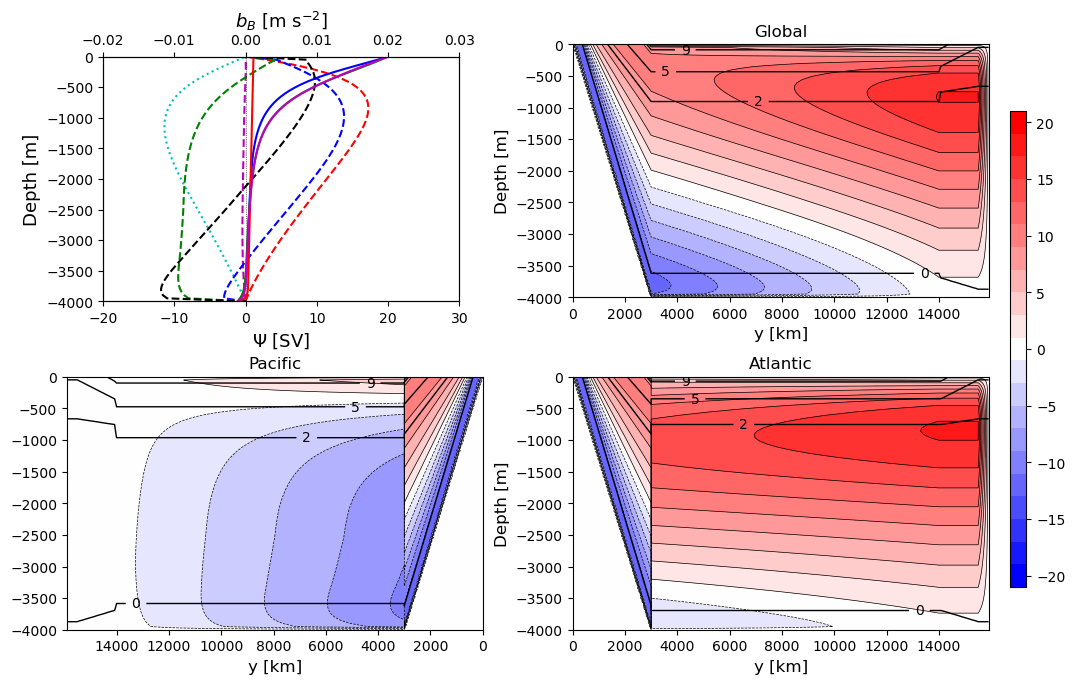

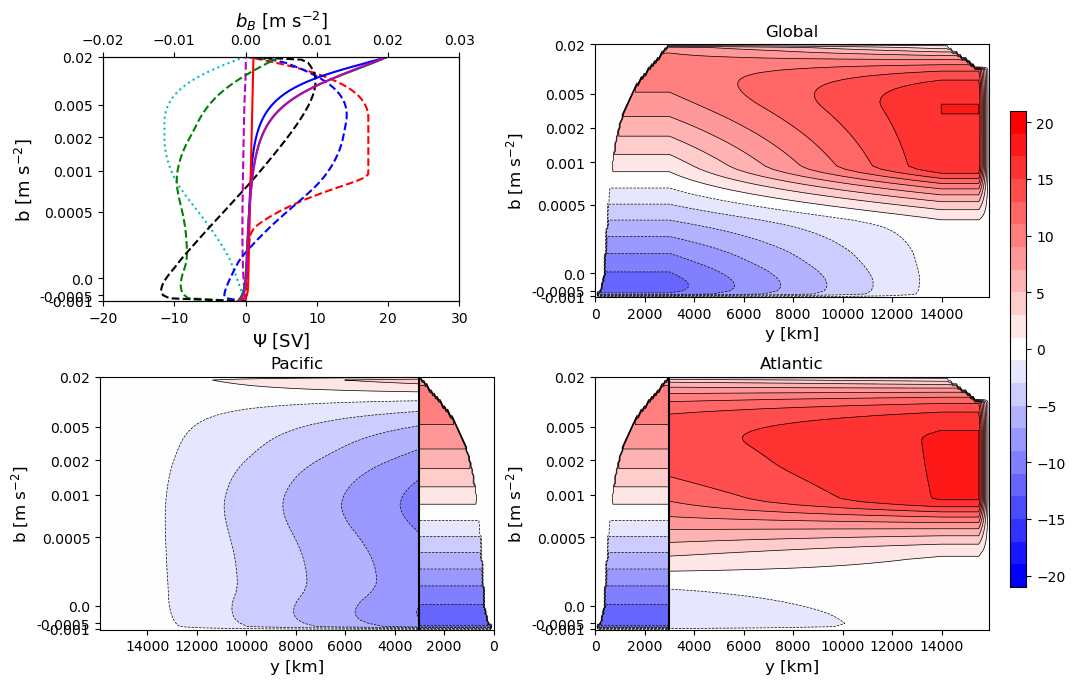

In [38]:
"""
Four-column MOC model, allowing for Northern sinking in the Pacific and the development of a PMOC.
"""

from pymoc.modules import Psi_Thermwind, Psi_SO, Column
from pymoc.plotting import Interpolate_channel, Interpolate_twocol
import numpy as np
from matplotlib import pyplot as plt

diag_file = None



#!!!
# bs_north_pac_vals = [0.0005,  0.005,  0.02] 
bs_north_pac_vals = [0.02] #, 0.00036] 


for bs_north_pac in bs_north_pac_vals:
    bs = 0.02;
    # the minimum surface buoyancy in the GCM in the North Atlantic is 3.5890e-04 (or 0.1795C)
    bs_north = 0.00036
    bAABW = -0.0011  # x1
    # bAABW = -0.0044  # x4
    
    bbot = min(bAABW, bs_north, bs_north_pac)

    # S.O. surface boundary conditions and grid:
    y = np.asarray(np.linspace(0, 3.e6, 51))
    tau = 0.16 # original 
    tau = 0.2
    offset = 0.0345*(1-np.cos(np.pi*(5.55e5-1.e5)/8e6));
    bs_SO = (0.0345*(1-np.cos(np.pi*(y-1.e5)/8e6))*(y>5.55e5)
          +(bAABW-offset)/5.55e5*np.maximum(0,5.55e5-y)+offset*(y<5.55e5));

    # time-stepping parameters:
    dt = 86400.*30.                               # time-step for vert. adv. diff. calc.
    MOC_up_iters = int(np.floor(2.*360*86400/dt)) # multiplier for MOC time-step (MOC is updated every MOC_up_iters time steps)
    plot_iters = int(np.ceil(500*360*86400/dt))   # plotting frequency (in iterations)
    total_iters = int(np.ceil(4000*360*86400/dt)) # total number of timesteps

    # Effective diffusivity profile          #original
    def kappaeff(z): # effective diffusivity profile with tapering in BBL
            return 1.0*( 1e-4*(1.1-np.tanh(np.maximum(z+2000.,0)/1000. + np.minimum(z+2000.,0)/1300.))
                    *(1.-np.maximum(-4000.-z+600.,0.)/600.)**2 )

    # def kappaeff(z): # effective diffusivity profile with tapering in BBL
    #         return 1.0*( 3e-5*(1.1-np.tanh(np.maximum(z+2000.,0)/1000. + np.minimum(z+2000.,0)/1300.))
    #                 *(1.-np.maximum(-4000.-z+600.,0.)/600.)**2 )
        
    # kappa = 3e-5 based on the quasi-constant (in the vertical) diffusivity inferred by Kunze (2017)
    # kappaeff = 3e-5 

    
    # a κ based on the bulk basin-wide estimate of Lumpkin and Speer (2007)
    

    A_Atl = 7e13#6e13  
    A_north_atl = 5.5e12
    # A_Pac = 1.7e14 #1.44e14      #old
    
    A_Pac = 1.7e14 - 5.5e12            #new
    A_north_pac = 5.5e12 #new 5.5e12
    
    Lx = 1.3e+07  #(length of the channel)
    Latl = 6./21.*Lx;
    Lpac = 15./21.*Lx;
    K = 1800.
    N2min = 2e-7
    
    z = np.asarray(np.linspace(-4000, 0, 80))
    
    # create initial guess for buoyancy profile in the Atl
    def b_Atl(z): return bs*np.exp(z/300.)+z/z[0]*bbot
    #def b_Atl(z): return 0.3*bs+z/z[0]*(bbot-0.3*bs)
    def b_Pac(z): return bs*np.exp(z/300.)+z/z[0]*bbot

    # create N.A. overturning model instance
    AMOC = Psi_Thermwind(z=z, b1=b_Atl, b2=0.01*b_Atl(z))
    # and solve for initial overturning streamfunction:
    AMOC.solve()
    # map North Atlantic overturning to isopycnal space:
    [Psi_iso_Atl, Psi_iso_N] = AMOC.Psibz()
    ####
    
    # create Pacific overturning model instance (PMOC) for North Pacific sinking
    PMOC = Psi_Thermwind(z=z, b1=b_Pac, b2=0.01*b_Pac(z))
    
    PMOC.solve()
    [Psi_iso_Pac, Psi_iso_NPac] = PMOC.Psibz()
    
    # create interbasin zonal overturning model instance
    ZOC = Psi_Thermwind(z=z, b1=b_Atl, b2=b_Pac, f=1e-4)
    # and solve for initial overturning streamfunction:
    ZOC.solve()
    # map inter-basin overturning to isopycnal space:
    [Psi_zonal_Atl, Psi_zonal_Pac] = ZOC.Psibz()
    
    # create S.O. overturning model instance for Atlantic sector
    SO_Atl = Psi_SO(z=z, y=y, b=b_Atl(z), bs=bs_SO, tau=tau, L=Latl, KGM=K)
    SO_Atl.solve()
    
    # create S.O. overturning model instance for Pacific sector
    SO_Pac = Psi_SO(z=z, y=y, b=b_Pac(z), bs=bs_SO, tau=tau, L=Lpac, KGM=K)
    SO_Pac.solve()

    
    
    # create adv-diff column model instance for Atl
    Atl = Column(z=z, kappa=kappaeff, b=b_Atl, bs=bs, bbot=bbot, Area=A_Atl, N2min=N2min)
    # create adv-diff column model instance for northern sinking region (Atlantic)
    north = Column(z=z, kappa=kappaeff, b=b_Atl, bs=bs_north, bbot=bbot, Area=A_north_atl, N2min=N2min)
    # create adv-diff column model instance for Pac
    Pac = Column(z=z, kappa=kappaeff, b=b_Pac, bs=bs, bbot=bbot, Area=A_Pac, N2min=N2min)
    # create adv-diff column model instance for northern Pacific sinking region
    ####### !!!!
    north_Pac = Column(z=z, kappa=kappaeff, b=b_Pac, bs=bs_north_pac, bbot=bbot, Area=A_north_pac, N2min=N2min)
    
    # Create figure:
    fig = plt.figure(figsize=(6,9))
    ax1 = fig.add_subplot(111)
    ax2 = ax1.twiny()
    plt.ylim((-4e3,0))
    ax1.set_xlim((-20,30))
    ax2.set_xlim((-0.02,0.030))
    
    # loop to iteratively find equilibrium solution
    for ii in range(0, total_iters):    
       # update buoyancy profile
       # using isopycnal overturning:
       wA_Atl = (Psi_iso_Atl + Psi_zonal_Atl - SO_Atl.Psi) * 1e6
       wAN = -Psi_iso_N * 1e6
       # Include Pacific isopycnal overturning contribution and SO residual
       wA_Pac = (-Psi_zonal_Pac - SO_Pac.Psi + Psi_iso_Pac) * 1e6
       wA_NPac = -Psi_iso_NPac * 1e6
    
       Atl.timestep(wA=wA_Atl, dt=dt)
       north.timestep(wA=wAN, dt=dt, do_conv=True)
       Pac.timestep(wA=wA_Pac, dt=dt)
       north_Pac.timestep(wA=wA_NPac, dt=dt, do_conv=True)
       
       if ii % MOC_up_iters == 0:
          # update overturning streamfunction (can be done less frequently)
          AMOC.update(b1=Atl.b, b2=north.b)
          AMOC.solve()
          [Psi_iso_Atl, Psi_iso_N] = AMOC.Psibz()
    
          PMOC.update(b1=Pac.b, b2=north_Pac.b)
          PMOC.solve()
          [Psi_iso_Pac, Psi_iso_NPac] = PMOC.Psibz()
    
          ZOC.update(b1=Atl.b, b2=Pac.b)
          ZOC.solve()
          [Psi_zonal_Atl, Psi_zonal_Pac] = ZOC.Psibz()
    
          SO_Atl.update(b=Atl.b)
          SO_Atl.solve()
          SO_Pac.update(b=Pac.b)
          SO_Pac.solve()
         
       if ii % plot_iters == 0:
          # Plot current state:
          ax1.plot(AMOC.Psi, AMOC.z,'--r', linewidth=0.5)
          ax1.plot(PMOC.Psi, PMOC.z,'--m', linewidth=0.5)         # Pacific overturning (PMOC)
          ax1.plot(ZOC.Psi, ZOC.z, ':c', linewidth=0.5)
          ax1.plot(SO_Atl.Psi-ZOC.Psi, SO_Atl.z, '--b', linewidth=0.5)
          ax1.plot(SO_Pac.Psi+ZOC.Psi, SO_Pac.z, '--g', linewidth=0.5)
          ax1.plot(SO_Atl.Psi+SO_Pac.Psi, z, '--c', linewidth=0.5)
          ax2.plot(Atl.b, Atl.z, '-b', linewidth=0.5)
          ax2.plot(Pac.b, Pac.z, '-g', linewidth=0.5)
          ax2.plot(north.b, north.z, '-r', linewidth=0.5)
          ax2.plot(north_Pac.b, north_Pac.z, '-m', linewidth=0.5)  # northern Pacific buoyancy
          plt.pause(0.01)
          print ( "t=", round(ii*dt/86400/360), "years")
     
    ax1.plot(AMOC.Psi, AMOC.z,'--r', linewidth=1.5)
    ax1.plot(PMOC.Psi, PMOC.z,'--m', linewidth=1.5)
    ax1.plot(ZOC.Psi, ZOC.z, ':c', linewidth=1.5)
    ax1.plot(SO_Atl.Psi-ZOC.Psi, SO_Atl.z, '--b', linewidth=1.5)
    ax1.plot(SO_Pac.Psi+ZOC.Psi, SO_Pac.z, '--g', linewidth=1.5)
    ax1.plot(SO_Atl.Psi+SO_Pac.Psi, z, '--c', linewidth=1.5)
    ax2.plot(Atl.b, Atl.z, '-b', linewidth=1.5)
    ax2.plot(Pac.b, Pac.z, '-g', linewidth=1.5)
    ax2.plot(north.b, north.z, '-r', linewidth=1.5)
    ax2.plot(north_Pac.b, north_Pac.z, '-m', linewidth=1.5)
    
    # Write out diagnostics (if diag file name is provided):
    if diag_file is not None:
       np.savez(diag_file, b_Atl=Atl.b, b_Pac=Pac.b, b_north=north.b, b_north_Pac=north_Pac.b,
                Psi_SO_Atl=SO_Atl.Psi, Psi_SO_Pac=SO_Pac.Psi,
                Psi_ZOC=ZOC.Psi, Psib_ZOC=ZOC.Psib(), bgrid_ZOC=ZOC.bgrid,
                Psi_AMOC=AMOC.Psi, Psib_AMOC=AMOC.Psib(), bgrid_AMOC=AMOC.bgrid,
                Psi_PMOC=PMOC.Psi, Psib_PMOC=PMOC.Psib(), bgrid_PMOC=PMOC.bgrid)
    
    # Plotting 
    
    blevs = np.array([-0.004,-0.002,0.0,0.004,0.01,0.018])
    plevs = np.arange(-21.,23.,2.0)
    nb = 500;
    
    b_basin = (A_Atl*Atl.b + A_Pac*Pac.b) / (A_Atl + A_Pac);
    
    #!!!!!
    b_north = (A_north_atl*north.b + A_north_pac*north_Pac.b) / (A_north_atl + A_north_pac);
    
    # Compute total SO residual overturning by first interpolating circulation 
    # in both sectors to mean buoyancy profile values and then summing (at constant b).
    PsiSO = (np.interp(b_basin, Atl.b, SO_Atl.Psi)
          + np.interp(b_basin, Pac.b, SO_Pac.Psi));
    
    AMOC_bbasin = np.interp(b_basin, AMOC.bgrid, AMOC.Psib(nb=nb));
    
    PMOC_bbasin = np.interp(b_basin, PMOC.bgrid, PMOC.Psib(nb=nb));   # new 
    # this is to Plot adiabatic overturning only:
    
    PsiSO_bgrid = (np.interp(AMOC.bgrid, Atl.b, SO_Atl.Psi)        #original version
                + np.interp(AMOC.bgrid, Pac.b, SO_Pac.Psi));
    
    # PsiSO_bgrid = (np.interp(AMOC.bgrid, Atl.b, SO_Atl.Psi)
    #             + np.interp(AMOC.bgrid, Pac.b, SO_Pac.Psi)
    #             + np.interp(PMOC.bgrid, Atl.b, SO_Atl.Psi)
    #             + np.interp(PMOC.bgrid, Pac.b, SO_Pac.Psi)) ;
    
    l = y[-1];
    
    bs = 1.*bs_SO
    bn = 1.*b_basin
    bs[-1] = 1.*bn[-1]; # if bs is tiny bit warmer there is a zero slope point at the surface which makes the interpolation fail...
    
    # first interpolate buoyancy in channel along constant-slope isopycnals: 
    bint = Interpolate_channel(y=y, z=z, bs=bs, bn=bn)
    bsouth = bint.gridit()
    # buoyancy in the basin is all the same:
    lbasin = 11000.
    ltrans = 1500.
    lnorth = 400.
    lchannel = l/1e3
    ybasin = np.linspace(0, lbasin, 60) + lchannel;
    bbasin = np.tile(b_basin, (len(ybasin), 1))
    bAtl = np.tile(Atl.b, (len(ybasin), 1))
    bPac = np.tile(Pac.b, (len(ybasin), 1))

    
    # interpolate buoyancy in northern transition region:
    ytrans = np.linspace(ltrans/20., ltrans, 20) + lchannel + lbasin;
    bn = b_north.copy();
    bn[0] = b_basin[0]; # Notice that the interpolation procedure assumes that the bottom
    #buoyancies in both columns match - which may not be exactly the case depending
    # on when in the time-step data is saved 
    bint = Interpolate_twocol(y=ytrans*1000.-ytrans[0]*1000., z=z, bs=Atl.b, bn=bn)
    btrans = bint.gridit()
    # finally set buyancy in northern deep water formation region:
    ynorth = np.linspace(lnorth/20., lnorth, 20) + lchannel + lbasin + ltrans;
    bnorth = np.tile(bn, (len(ynorth), 1))
    bnorth_atl = np.tile(bn, (len(ynorth), 1))
    bnorth_pac = np.tile(bn, (len(ynorth), 1))
    # now stick it all together:
    ynew = np.concatenate((y/1e3, ybasin, ytrans, ynorth))
    bnew = np.concatenate((bsouth, bbasin, btrans, bnorth))
    bnew_Atl = np.concatenate((bsouth, bAtl, btrans, bnorth_atl))
    bnew_Pac = np.concatenate((bsouth, bPac, btrans, bnorth_pac))    ## new
    
    # Compute z-coordinate and residual overturning streamfunction at all latitudes:
    psiarray_b = np.zeros((len(ynew), len(z))) # overturning in b-coordinates
    psiarray_b_Atl = np.zeros((len(ynew), len(z))) # overturning in b-coordinates
    psiarray_b_Pac = np.zeros((len(ynew), len(z))) # overturning in b-coordinates
    psiarray_Atl = np.zeros((len(ynew), len(z))) # "residual" overturning in ATl.
    psiarray_Pac = np.zeros((len(ynew), len(z))) # "residual" overturning in Pac.
    psiarray_z = np.zeros((len(ynew), len(z)))  # z-space, "eulerian" overturning
    psiarray_z_Atl = np.zeros((len(ynew), len(z)))  # z-space, "eulerian" overturning
    psiarray_z_Pac = np.zeros((len(ynew), len(z)))  # z-space, "eulerian" overturning
    
    # for iy in range(1, len(y)):
    #     psiarray_z[iy,:] = np.interp(bnew[iy,:], b_basin, (SO_Atl.Psi + SO_Pac.Psi) )
        
    #     psiarray_z_Atl[iy,:] = np.interp(bnew[iy,:], b_basin, SO_Atl.Psi)
    #     psiarray_z_Pac[iy,:] = np.interp(bnew[iy,:], b_basin, SO_Pac.Psi)
    
    #     psiarray_b[iy, b_basin < bs_SO[iy]] = PsiSO[b_basin < bs_SO[iy]]
        
    #     psiarray_Atl[iy, b_basin < bs_SO[iy]] = np.interp(b_basin[b_basin < bs_SO[iy]], b_basin, SO_Atl.Psi)[:]
    #     psiarray_b_Atl[iy, b_basin < bs_SO[iy]] = psiarray_Atl[iy, b_basin < bs_SO[iy]]
        
    #     psiarray_Pac[iy, b_basin < bs_SO[iy]] = np.interp(b_basin[b_basin < bs_SO[iy]], b_basin, SO_Pac.Psi)[:]
    #     psiarray_b_Pac[iy, b_basin < bs_SO[iy]] = psiarray_Pac[iy, b_basin < bs_SO[iy]]

    for iy in range(1,len(y)):
        # in the channel, interpolate PsiSO onto local isopycnal depth:
        psiarray_z[iy,:]=np.interp(bnew[iy,:],b_basin,SO_Atl.Psi+SO_Pac.Psi)
        psiarray_z_Atl[iy,:]=psiarray_z[iy,:]
        psiarray_z_Pac[iy,:]=psiarray_z[iy,:]
        psiarray_b[iy,b_basin<bs_SO[iy]]=PsiSO[b_basin<bs_SO[iy]]
        psiarray_Atl[iy,:]=np.interp(bnew[iy,:],b_basin,PsiSO);    
        psiarray_b_Atl[iy,:]=psiarray_b[iy,:];    
        psiarray_Pac[iy,:]=np.interp(bnew[iy,:],b_basin,PsiSO)   
        psiarray_b_Pac[iy,:]=psiarray_b[iy,:]; 

        



    for iy in range(len(y), len(y)+len(ybasin)):
        psiarray_z[iy,:] = ((ynew[iy]-lchannel)*(AMOC.Psi + PMOC.Psi)
                            + (lchannel + lbasin - ynew[iy])*(SO_Atl.Psi + SO_Pac.Psi))/lbasin
    
        psiarray_z_Atl[iy,:] = ((ynew[iy]-lchannel)*AMOC.Psi
                                 + (lchannel + lbasin - ynew[iy])*(SO_Atl.Psi - ZOC.Psi))/lbasin
    
        psiarray_z_Pac[iy,:] = ((ynew[iy]-lchannel)*PMOC.Psi
                                 + (lchannel + lbasin - ynew[iy])*(SO_Pac.Psi + ZOC.Psi))/lbasin
    
        psiarray_b[iy,:] = ((ynew[iy]-lchannel)*(AMOC_bbasin + PMOC_bbasin)
                            + (lchannel + lbasin - ynew[iy])*PsiSO)/lbasin

        
        psiarray_Atl[iy,:]=((ynew[iy]-lchannel)*AMOC.Psibz(nb=nb)[0]+(lchannel+lbasin-ynew[iy])*(SO_Atl.Psi-ZOC.Psibz()[0]))/lbasin   
        psiarray_b_Atl[iy,:]=((ynew[iy]-lchannel)*AMOC_bbasin+
                        (lchannel+lbasin-ynew[iy])*(np.interp(b_basin,Atl.b,SO_Atl.Psi)
                          -np.interp(b_basin,ZOC.bgrid,ZOC.Psib())))/lbasin
        
        psiarray_Pac[iy,:]=((ynew[iy]-lchannel)*PMOC.Psibz(nb=nb)[0]+(lchannel+lbasin-ynew[iy])*(SO_Pac.Psi+ZOC.Psibz()[0]))/lbasin   
        psiarray_b_Pac[iy,:]=((ynew[iy]-lchannel)*PMOC_bbasin+
                        (lchannel+lbasin-ynew[iy])*(np.interp(b_basin,Pac.b,SO_Pac.Psi)
                          +np.interp(b_basin,ZOC.bgrid,ZOC.Psib())))/lbasin

        
    
        # psiarray_Atl[iy,:] = ((ynew[iy]-lchannel)*AMOC.Psibz(nb=nb)[0]
        #                       + (lchannel + lbasin - ynew[iy])*(np.interp(b_basin, Atl.b, SO_Atl.Psi)
        #                                                        - np.interp(b_basin, ZOC.bgrid, ZOC.Psib())))/lbasin
    
        # psiarray_b_Atl[iy,:] = ((ynew[iy]-lchannel)*np.interp(b_basin, Atl.b, AMOC_bbasin)
        #                          + (lchannel + lbasin - ynew[iy])*np.interp(b_basin, Atl.b, SO_Atl.Psi)
        #                          - (lchannel + lbasin - ynew[iy])*np.interp(b_basin, ZOC.bgrid, ZOC.Psib()))/lbasin
    
        # psiarray_Pac[iy,:] = ((ynew[iy]-lchannel)*PMOC.Psibz()[0]
        #                       + (lchannel + lbasin - ynew[iy])*(SO_Pac.Psi + ZOC.Psibz()[0]))/lbasin
    
        # psiarray_b_Pac[iy,:] = ((ynew[iy]-lchannel)*np.interp(b_basin, Pac.b, PMOC_bbasin)
        #                          + (lchannel + lbasin - ynew[iy])*np.interp(b_basin, Pac.b, SO_Pac.Psi)
        #                          + (lchannel + lbasin - ynew[iy])*np.interp(b_basin, ZOC.bgrid, ZOC.Psib()))/lbasin
        
            
    
    for iy in range(len(y)+len(ybasin), len(y)+len(ybasin)+len(ytrans)):
        # in the northern transition region keep psi_z constant 
        # and psi_b constant on non-outcropped isopycnals (but zero on outcropped
        # isopycnals):
        psiarray_z[iy,:] = (AMOC.Psi + PMOC.Psi) 
        psiarray_z_Atl[iy,:] = AMOC.Psi
        psiarray_z_Pac[iy,:] = PMOC.Psi

        psiarray_b[iy, b_basin < bnew[iy,-1]] = AMOC_bbasin[b_basin < bnew[iy,-1]] + PMOC_bbasin[b_basin < bnew[iy,-1]]
        psiarray_Atl[iy, b_basin < bnew[iy,-1]] = AMOC_bbasin[b_basin < bnew[iy,-1]]
        psiarray_b_Atl[iy, b_basin < bnew[iy,-1]] = psiarray_Atl[iy, b_basin < bnew[iy,-1]]
        psiarray_Pac[iy, b_basin < bnew[iy,-1]] = PMOC_bbasin[b_basin < bnew[iy,-1]]
        psiarray_b_Pac[iy, b_basin < bnew[iy,-1]] = psiarray_Pac[iy, b_basin < bnew[iy,-1]]
    
    
    for iy in range(len(y)+len(ybasin)+len(ytrans), len(ynew)):
            # in the northern sinking region, all psi decrease linearly to zero:

        factor = (lchannel + lbasin + ltrans + lnorth - ynew[iy]) / lnorth
        factor = max(0.0, (lchannel + lbasin + ltrans + lnorth - ynew[iy]) / lnorth)

    
        psiarray_z[iy,:] = factor * (AMOC.Psi + PMOC.Psi)
        psiarray_z_Atl[iy,:] = factor * AMOC.Psi
        psiarray_z_Pac[iy,:] = factor * PMOC.Psi

        # psiarray_b[iy, b_basin < bnew[iy,-1]] = factor * (AMOC_bbasin[b_basin < bnew[iy,-1]] + PMOC_bbasin[b_basin < bnew[iy,-1]])
    
        psiarray_b[iy, b_basin < bnew[iy,-1]] = factor * (AMOC_bbasin[b_basin < bnew[iy,-1]] + PMOC_bbasin[b_basin < bnew[iy,-1]])
        psiarray_Atl[iy, b_basin < bnew[iy,-1]] = factor * AMOC_bbasin[b_basin < bnew[iy,-1]]
        psiarray_b_Atl[iy, b_basin < bnew[iy,-1]] = psiarray_Atl[iy, b_basin < bnew[iy,-1]]
        psiarray_Pac[iy, b_basin < bnew[iy,-1]] = factor * PMOC_bbasin[b_basin < bnew[iy,-1]]
        psiarray_b_Pac[iy, b_basin < bnew[iy,-1]] = psiarray_Pac[iy, b_basin < bnew[iy,-1]]

    
    
    # plot z-coordinate overturning and buoyancy structure:
        
    fig = plt.figure(figsize=(10.8,6.8))
    ax1 =fig.add_axes([0.1,.57,.33,.36])
    ax2 = ax1.twiny()
    plt.ylim((-4e3,0))
    ax1.set_ylabel('Depth [m]', fontsize=13)
    ax1.set_xlim((-20,30))
    ax2.set_xlim((-0.02,0.030))
    ax1.set_xlabel('$\Psi$ [SV]', fontsize=13)
    ax2.set_xlabel('$b_B$ [m s$^{-2}$]', fontsize=13)
    ax1.plot(AMOC.Psi, AMOC.z,'--r', linewidth=1.5)
    ax1.plot(PMOC.Psi, PMOC.z,'--m', linewidth=1.5)  # PMOC plotted here as well
    ax1.plot(ZOC.Psi, ZOC.z, ':c', linewidth=1.5)
    ax1.plot(SO_Atl.Psi-ZOC.Psi, SO_Atl.z, '--b', linewidth=1.5)
    ax1.plot(SO_Pac.Psi+ZOC.Psi, SO_Pac.z, '--g', linewidth=1.5)
    ax1.plot(SO_Atl.Psi+SO_Pac.Psi, z, '--k', linewidth=1.5)
    ax2.plot(Atl.b, Atl.z, '-b', linewidth=1.5)
    ax2.plot(Pac.b, Pac.z, '-g', linewidth=1.5)
    ax2.plot(north.b, north.z, '-r', linewidth=1.5)
    ax2.plot(north_Pac.b, north_Pac.z, '-m', linewidth=1.5)
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1+h2, l1+l2, loc=4, frameon=False)
    ax1.plot(0.*z, z,linewidth=0.5,color='k',linestyle=':')
    
    ax1 = fig.add_subplot(222)
    CS = ax1.contour(ynew, z, bnew.transpose()/2e-3, levels=blevs/2e-3, colors='k', linewidths=1.0, linestyles='solid')
    ax1.clabel(CS, fontsize=10, fmt='%1.0f')
    ax1.contour(ynew, z, psiarray_z.transpose(), levels=plevs, colors='k', linewidths=0.5)
    CS = ax1.contourf(ynew, z, psiarray_z.transpose(), levels=plevs, cmap=plt.cm.bwr, vmin=-20, vmax=20)
    ax1.set_xlim([0, ynew[-1]])
    ax1.set_xlabel('y [km]', fontsize=12)
    ax1.set_ylabel('Depth [m]', fontsize=12)
    ax1.set_title('Global', fontsize=12)
           
    ax1 = fig.add_subplot(223)
    CS = ax1.contour(ynew, z, bnew_Pac.transpose()/2e-3, levels=blevs/2e-3, colors='k', linewidths=1.0, linestyles='solid')
    ax1.clabel(CS, fontsize=10, fmt='%1.0f')
    ax1.contour(ynew, z, psiarray_z_Pac.transpose(), levels=plevs, colors='k', linewidths=0.5)
    CS = ax1.contourf(ynew, z, psiarray_z_Pac.transpose(), levels=plevs, cmap=plt.cm.bwr, vmin=-20, vmax=20)
    ax1.set_xlim([0, ynew[-1]])
    ax1.set_xlabel('y [km]', fontsize=12)
    ax1.set_title('Pacific', fontsize=12)
    plt.gca().invert_xaxis()
    
    ax1 = fig.add_subplot(224)
    CS = ax1.contour(ynew, z, bnew_Atl.transpose()/2e-3, levels=blevs/2e-3, colors='k', linewidths=1.0, linestyles='solid')
    ax1.clabel(CS, fontsize=10, fmt='%1.0f')
    ax1.contour(ynew, z, psiarray_z_Atl.transpose(), levels=plevs, colors='k', linewidths=0.5)
    CS = ax1.contourf(ynew, z, psiarray_z_Atl.transpose(), levels=plevs, cmap=plt.cm.bwr, vmin=-20, vmax=20)
    ax1.set_xlim([0, ynew[-1]])
    ax1.set_xlabel('y [km]', fontsize=12)
    ax1.set_ylabel('Depth [m]', fontsize=12)
    ax1.set_title('Atlantic', fontsize=12)
    
    cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
    fig.tight_layout()   
    fig.subplots_adjust(right=0.92)
    fig.colorbar(CS, cax=cbar_ax, ticks=np.arange(-20,21,5), orientation='vertical')

    plt.savefig(f'Test_Buoyancy_Forcing_DEPTH_VIEW{bs_north_pac:.4f}.png')
    # plt.close('all')
    
    # Plot Isopycnal overturning
    
    fig = plt.figure(figsize=(10.8,6.8))
    ax1 =fig.add_axes([0.1,.57,.33,.36])
    ax2 = ax1.twiny()
    plt.ylim((-4e3,0))
    ax1.set_ylabel('b [m s$^{-2}$]', fontsize=13)
    ax1.set_xlim((-20,30))
    ax2.set_xlim((-0.02,0.030))
    ax1.set_xlabel('$\Psi$ [SV]', fontsize=13)
    ax2.set_xlabel('$b_B$ [m s$^{-2}$]', fontsize=13)
    ax1.plot(AMOC_bbasin, z,'--r', linewidth=1.5)
    
    
    # plot PMOC mapped onto same b-grid where useful (interpolation used analogously to ZOC mapping)
    ax1.plot(np.interp(b_basin, PMOC.bgrid, PMOC.Psib()), z, '--m', linewidth=1.5)
    ax1.plot(np.interp(b_basin, ZOC.bgrid, ZOC.Psib()), z, ':c', linewidth=1.5)
    ax1.plot(np.interp(b_basin, Atl.b, SO_Atl.Psi)
            -np.interp(b_basin, ZOC.bgrid, ZOC.Psib()), z, '--b', linewidth=1.5)
    ax1.plot(np.interp(b_basin, Pac.b, SO_Pac.Psi)
              +np.interp(b_basin, ZOC.bgrid, ZOC.Psib()), z, '--g', linewidth=1.5)
    ax1.plot(PsiSO, z, '--k', linewidth=1.5)
    ax2.plot(Atl.b, Atl.z, '-b', linewidth=1.5)
    ax2.plot(Pac.b, Pac.z, '-g', linewidth=1.5)
    ax2.plot(north.b, north.z, '-r', linewidth=1.5)
    ax2.plot(north_Pac.b, north_Pac.z, '-m', linewidth=1.5)     
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1+h2, l1+l2, loc=4, frameon=False)
    ax1.plot(0.*b_basin, b_basin,linewidth=0.5,color='k',linestyle=':')
    ax1.set_yticks(np.interp([0.02, 0.005,0.002,0.001,0.0005, 0.,-0.0005, -0.001 ], b_basin, z))
    ax1.set_yticklabels([0.02, 0.005,0.002, 0.001,0.0005, 0.,-0.0005, -0.001 ])
    
    ax1 = fig.add_subplot(222)
    ax1.contour(ynew, z, psiarray_b.transpose(), levels=plevs, colors='k', linewidths=0.5)
    CS = ax1.contourf(ynew, z, psiarray_b.transpose(), levels=plevs, cmap=plt.cm.bwr, vmin=-20, vmax=20)
    ax1.set_xlim([0, ynew[-1]])
    ax1.set_xlabel('y [km]', fontsize=12)
    ax1.set_ylabel('b [m s$^{-2}$]', fontsize=12)
    ax1.set_title('Global', fontsize=12)
    ax1.set_yticks(np.interp([0.02, 0.005,0.002,0.001,0.0005, 0.,-0.0005, -0.001 ], b_basin, z))
    ax1.set_yticklabels([0.02, 0.005,0.002, 0.001,0.0005, 0.,-0.0005, -0.001 ])
           
    ax1 = fig.add_subplot(223)
    ax1.contour(ynew, z, psiarray_b_Pac.transpose(), levels=plevs, colors='k', linewidths=0.5)
    CS = ax1.contourf(ynew, z, psiarray_b_Pac.transpose(), levels=plevs, cmap=plt.cm.bwr, vmin=-20, vmax=20)
    ax1.plot(np.array([y[-1]/1000., y[-1]/1000.]), np.array([-4000.,0.]), color='k')
    ax1.set_xlim([0, ynew[-1]])
    ax1.set_xlabel('y [km]', fontsize=12)
    ax1.set_ylabel('b [m s$^{-2}$]', fontsize=12)
    ax1.set_title('Pacific', fontsize=12)
    ax1.set_yticks(np.interp([0.02, 0.005,0.002,0.001,0.0005, 0.,-0.0005, -0.001 ], b_basin, z))
    ax1.set_yticklabels([0.02, 0.005,0.002, 0.001,0.0005, 0.,-0.0005, -0.001 ])
    plt.gca().invert_xaxis()
    
    ax1 = fig.add_subplot(224)
    ax1.contour(ynew, z, psiarray_b_Atl.transpose(), levels=plevs, colors='k', linewidths=0.5)
    CS = ax1.contourf(ynew, z, psiarray_b_Atl.transpose(), levels=plevs, cmap=plt.cm.bwr, vmin=-20, vmax=20)
    ax1.plot(np.array([y[-1]/1000., y[-1]/1000.]), np.array([-4000.,0.]), color='k')
    ax1.set_xlim([0, ynew[-1]])
    ax1.set_xlabel('y [km]', fontsize=12)
    ax1.set_ylabel('b [m s$^{-2}$]', fontsize=12)
    ax1.set_title('Atlantic', fontsize=12)
    ax1.set_yticks(np.interp([0.02, 0.005,0.002,0.001,0.0005, 0.,-0.0005, -0.001 ], b_basin, z))
    ax1.set_yticklabels([0.02, 0.005,0.002, 0.001,0.0005, 0.,-0.0005, -0.001 ])
    
    cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
    fig.tight_layout()   
    fig.subplots_adjust(right=0.92)
    fig.colorbar(CS, cax=cbar_ax, ticks=np.arange(-20,25,5), orientation='vertical')

    # def find_max_location(psi2d, yvec, zvec):
    #     flat = np.ravel(psi2d)
    #     idx = np.nanargmax(np.abs(flat))
    #     iy, iz = np.unravel_index(idx, psi2d.shape)
    #     value = psi2d[iy, iz]
    #     return value, yvec[iy], zvec[iz], iy, iz
    
    # results = {}
    
    # results['AMOC'] = (AMOC.Psi.max(), AMOC.z[np.nanargmax(AMOC.Psi)], None, None, None)
    # results['AMOC_abs'] = (np.max(np.abs(AMOC.Psi)), AMOC.z[np.nanargmax(np.abs(AMOC.Psi))], None, None, None)
    # results['PMOC'] = (PMOC.Psi.max(), PMOC.z[np.nanargmax(PMOC.Psi)], None, None, None)
    # results['ZOC'] = (ZOC.Psi.max(), ZOC.z[np.nanargmax(ZOC.Psi)], None, None, None)
    
    # results['Global_z'] = find_max_location(psiarray_z, ynew, z)
    # results['Pacific_z'] = find_max_location(psiarray_z_Pac, ynew, z)
    # results['Atlantic_z'] = find_max_location(psiarray_z_Atl, ynew, z)
    
    # results['Global_b'] = find_max_location(psiarray_b, ynew, z)
    # results['Pacific_b'] = find_max_location(psiarray_b_Pac, ynew, z)
    # results['Atlantic_b'] = find_max_location(psiarray_b_Atl, ynew, z)
    
    # for k, v in results.items():
    #     if v[2] is None:
    #         print(f"{k}: max = {v[0]:.3f} SV at depth {v[1]:.1f} m")
    #     else:
    #         print(f"{k}: max = {v[0]:.3f} SV at y = {v[1]:.1f} km, depth = {v[2]:.1f} m (indices {v[3]}, {v[4]})")

    # plt.savefig(f'Test_Buoyancy_Forcing_ISOPYCNALS_VIEW{bs_north_pac:.4f}.png')
    # plt.close('all')

              
    plt.show()

In [40]:
bs_SO

array([-1.10000000e-03, -9.21701902e-04, -7.43403804e-04, -5.65105706e-04,
       -3.86807608e-04, -2.08509510e-04, -3.02114125e-05,  1.48086685e-04,
        3.26384783e-04,  5.04682881e-04,  6.62907826e-04,  8.30871713e-04,
        1.01752667e-03,  1.22276906e-03,  1.44648497e-03,  1.68855019e-03,
        1.94883034e-03,  2.22718094e-03,  2.52344745e-03,  2.83746541e-03,
        3.16906050e-03,  3.51804864e-03,  3.88423608e-03,  4.26741954e-03,
        4.66738630e-03,  5.08391433e-03,  5.51677239e-03,  5.96572019e-03,
        6.43050849e-03,  6.91087928e-03,  7.40656588e-03,  7.91729312e-03,
        8.44277748e-03,  8.98272722e-03,  9.53684262e-03,  1.01048160e-02,
        1.06863322e-02,  1.12810683e-02,  1.18886941e-02,  1.25088724e-02,
        1.31412587e-02,  1.37855022e-02,  1.44412451e-02,  1.51081235e-02,
        1.57857670e-02,  1.64737995e-02,  1.71718391e-02,  1.78794982e-02,
        1.85963841e-02,  1.93220986e-02,  2.00562391e-02])

In [42]:
print(bsouth)

[[-0.0011     -0.0011     -0.0011     ... -0.0011     -0.0011
  -0.0011    ]
 [-0.0011     -0.0011     -0.0011     ... -0.0011     -0.00103398
  -0.0009217 ]
 [-0.0011     -0.0011     -0.0011     ... -0.00096681 -0.00085413
  -0.0007434 ]
 ...
 [-0.0011     -0.0011     -0.0011     ...  0.01618595  0.01740415
   0.01859638]
 [-0.0011     -0.0011     -0.00096019 ...  0.01690909  0.01812864
   0.0193221 ]
 [-0.0011     -0.00075308 -0.00049285 ...  0.01764968  0.01886271
   0.02      ]]


In [39]:
import inspect

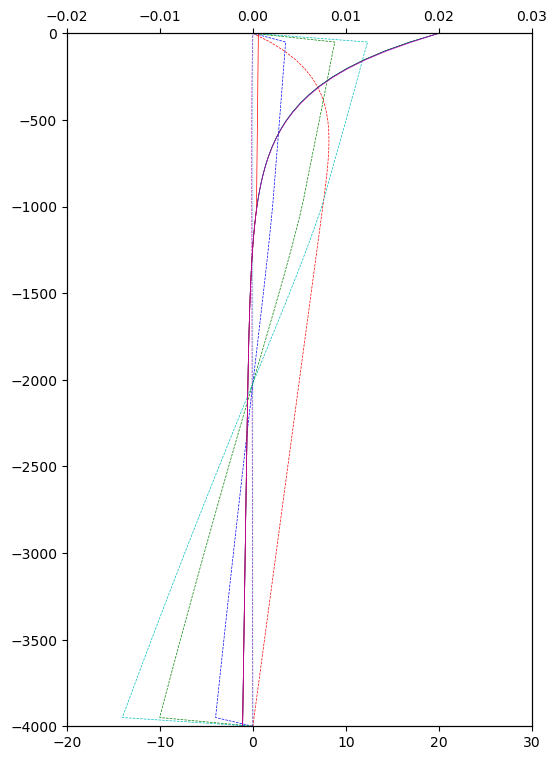

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.101 SV at depth -759.5 m
AMOC_abs: max = 14.101 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = -0.000 SV at depth -4000.0 m
Global_z: max = -15.108 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.108 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.108 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.076 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.076 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.076 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


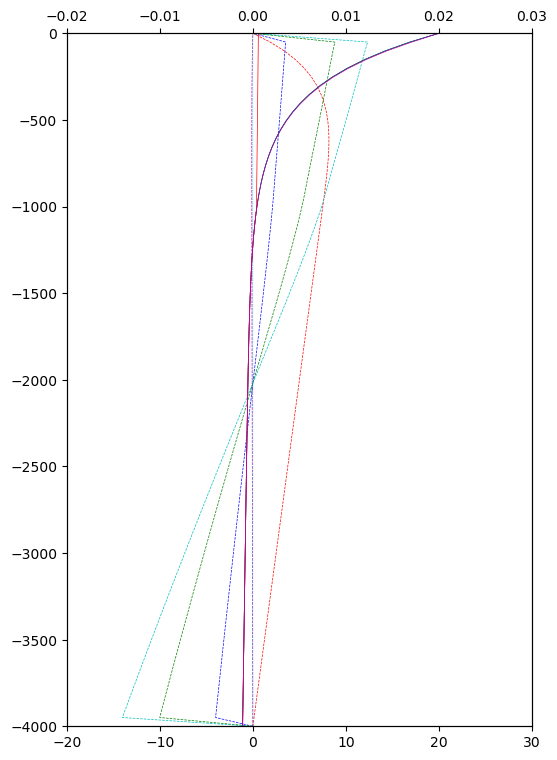

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.099 SV at depth -759.5 m
AMOC_abs: max = 14.099 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.109 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.109 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.109 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.077 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.077 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.077 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


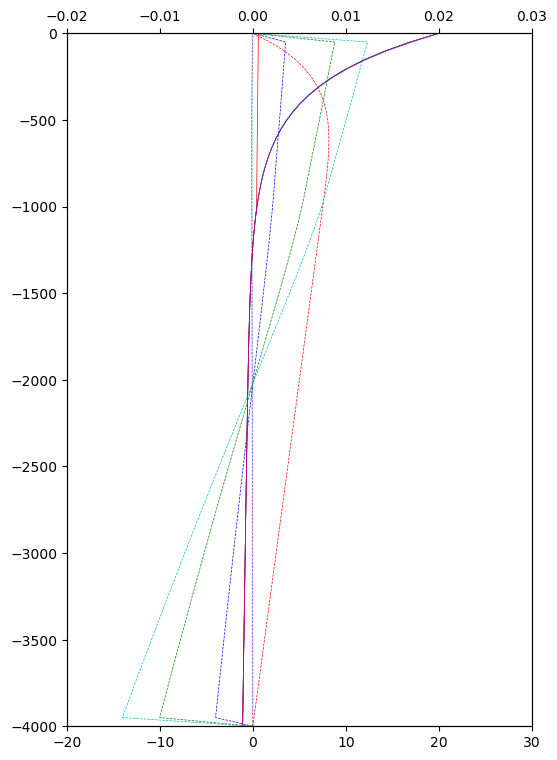

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.097 SV at depth -759.5 m
AMOC_abs: max = 14.097 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.109 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.109 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.109 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.077 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.077 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.077 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


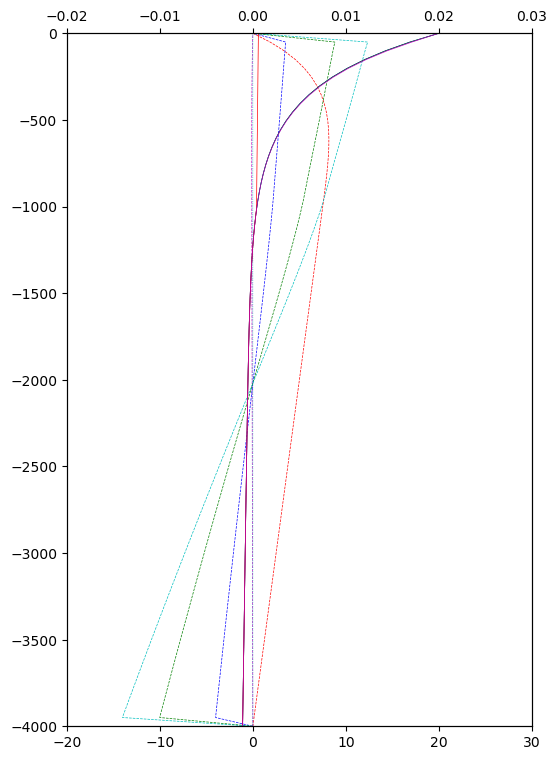

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.095 SV at depth -759.5 m
AMOC_abs: max = 14.095 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = -0.000 SV at depth -4000.0 m
Global_z: max = -15.110 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.110 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.110 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.078 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.078 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.078 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


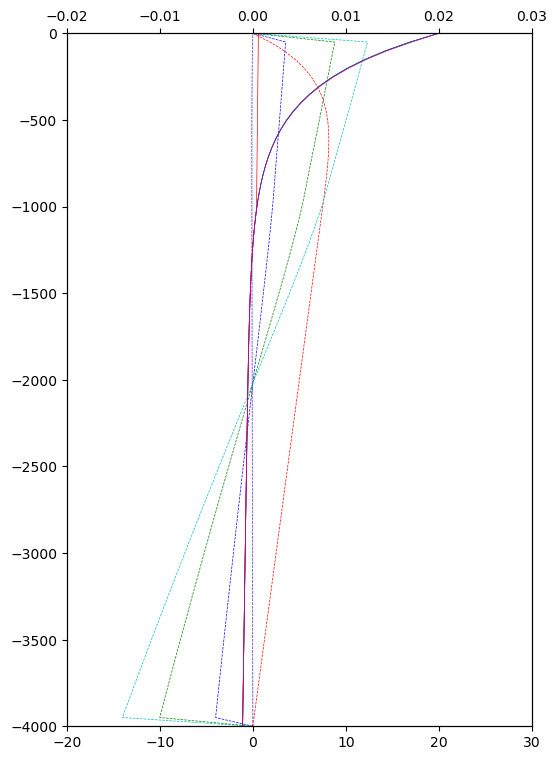

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.092 SV at depth -759.5 m
AMOC_abs: max = 14.092 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth -4000.0 m
Global_z: max = -15.110 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.110 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.110 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.078 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.078 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.078 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


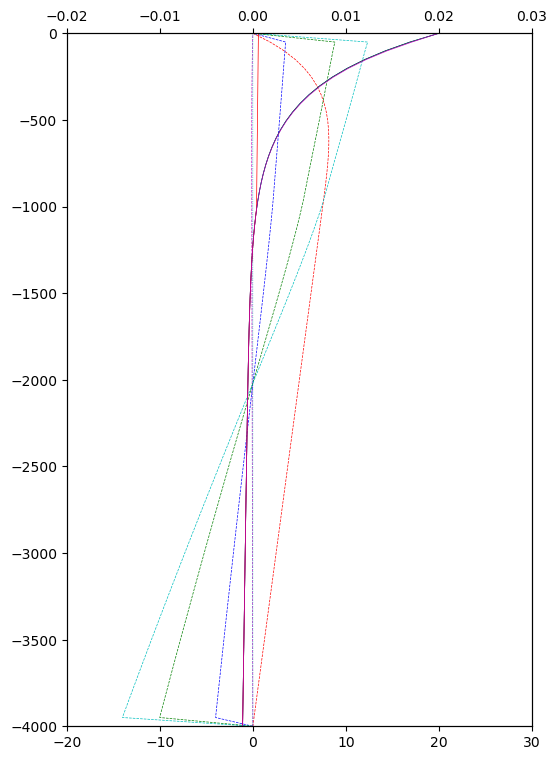

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.090 SV at depth -759.5 m
AMOC_abs: max = 14.090 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.111 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.111 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.111 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.079 SV at y = 3000.0 km, depth = -3848.1 m (indices 51, 3)
Pacific_b: max = -15.079 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.079 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


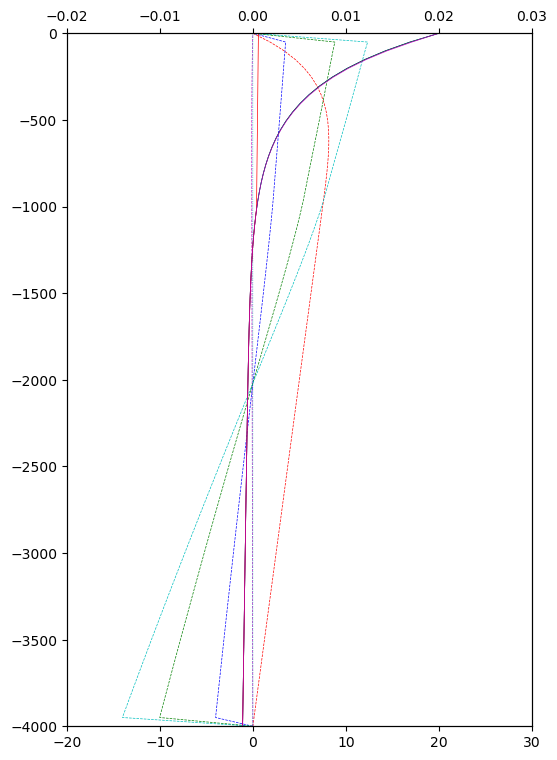

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.088 SV at depth -759.5 m
AMOC_abs: max = 14.088 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.111 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.111 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.111 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.080 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.080 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.080 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


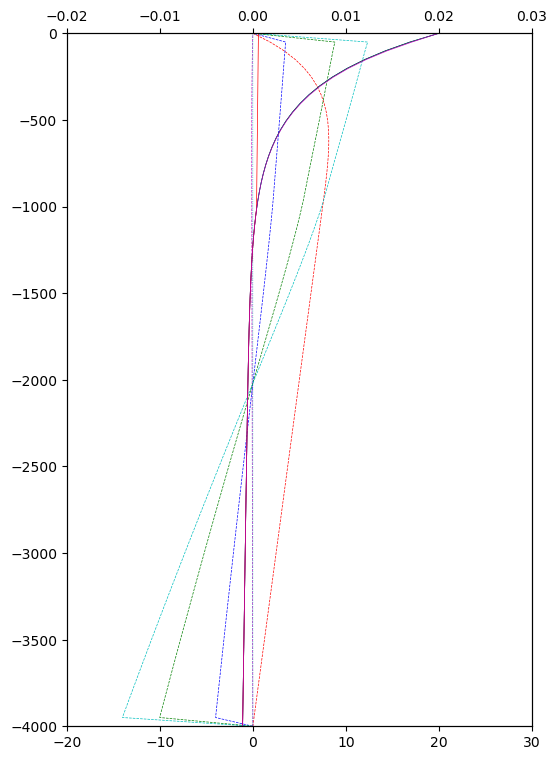

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.086 SV at depth -759.5 m
AMOC_abs: max = 14.086 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.112 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.112 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.112 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.080 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.080 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.080 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


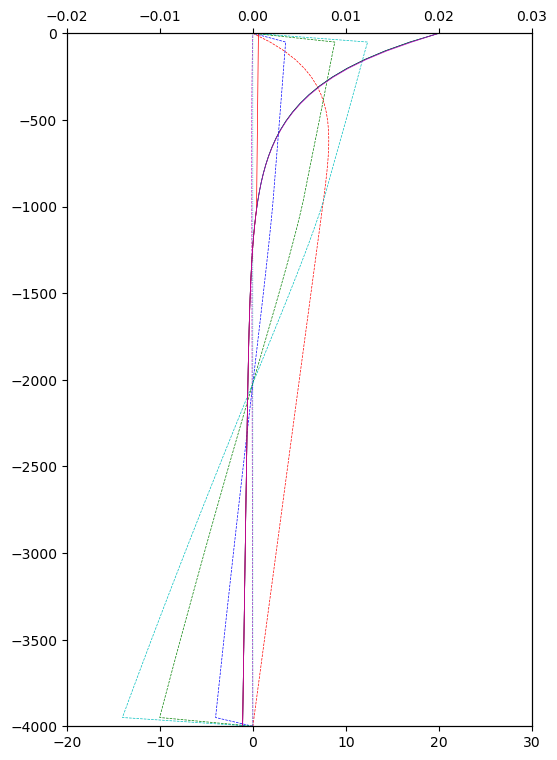

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.084 SV at depth -759.5 m
AMOC_abs: max = 14.084 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.113 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.113 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.113 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.081 SV at y = 3000.0 km, depth = -3848.1 m (indices 51, 3)
Pacific_b: max = -15.081 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.081 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


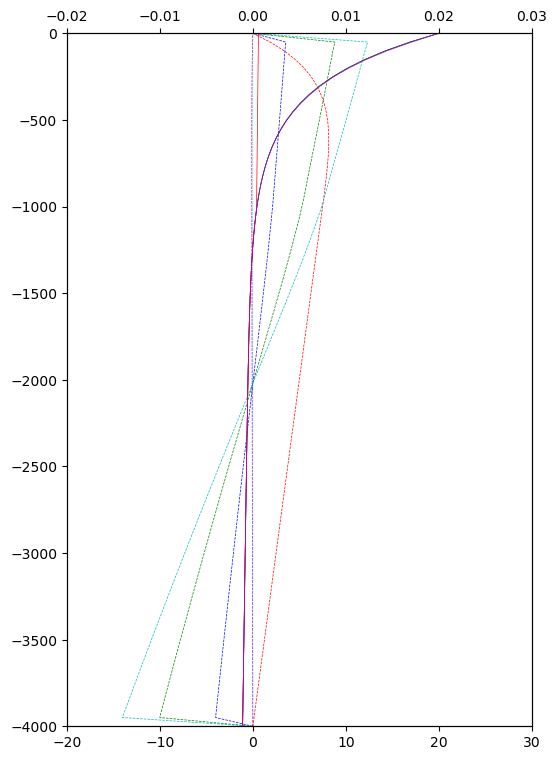

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.082 SV at depth -759.5 m
AMOC_abs: max = 14.082 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.113 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.113 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.113 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.081 SV at y = 3000.0 km, depth = -3848.1 m (indices 51, 3)
Pacific_b: max = -15.081 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.081 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


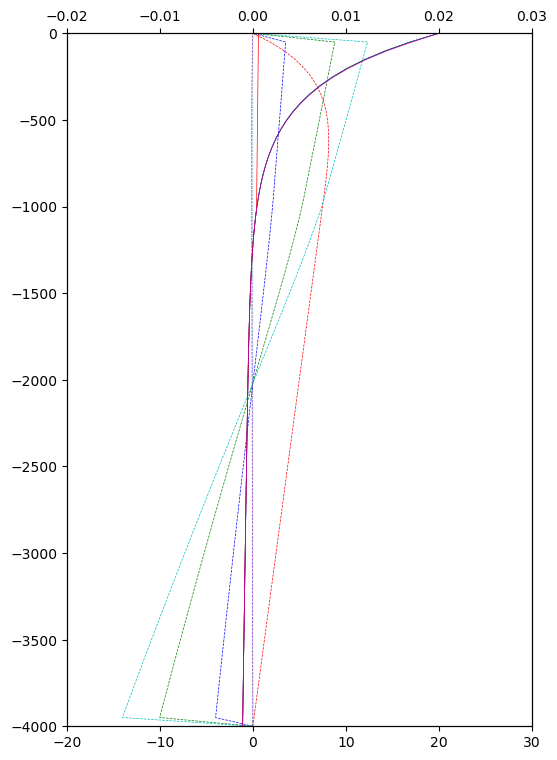

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.080 SV at depth -759.5 m
AMOC_abs: max = 14.080 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.114 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.114 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.114 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.082 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.082 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.082 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


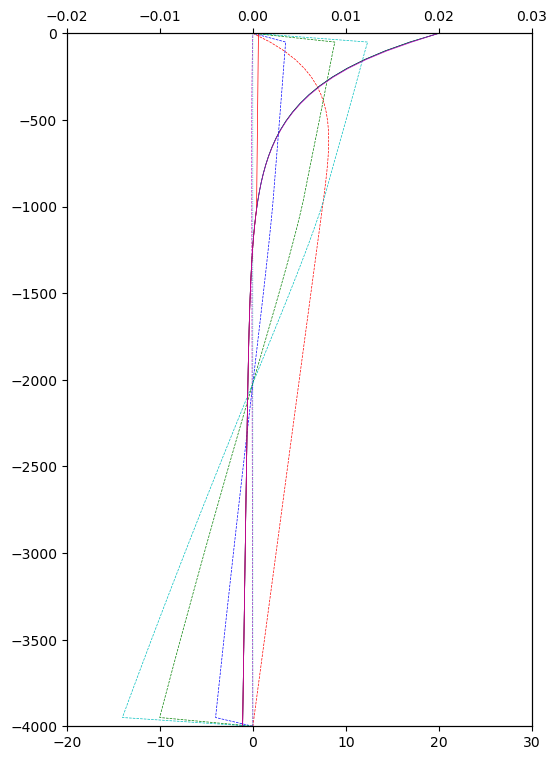

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.078 SV at depth -759.5 m
AMOC_abs: max = 14.078 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.114 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.114 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.114 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.082 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.082 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.082 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


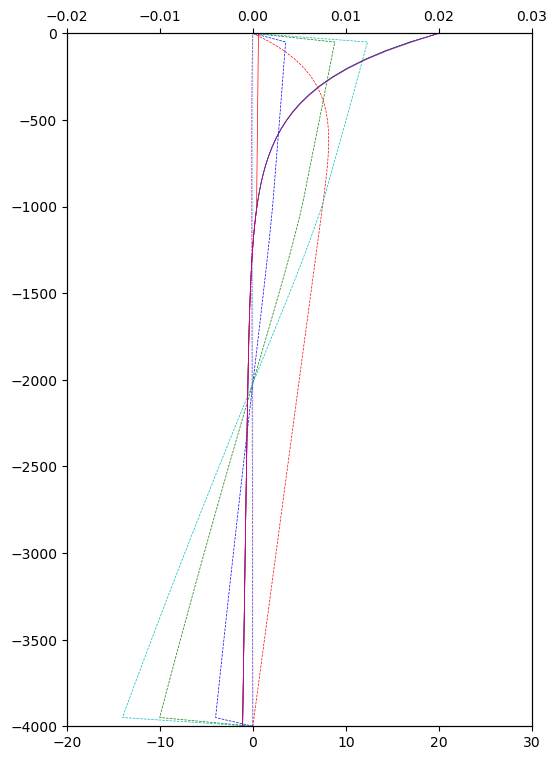

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.076 SV at depth -759.5 m
AMOC_abs: max = 14.076 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.115 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.115 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.115 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.083 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.083 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.083 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


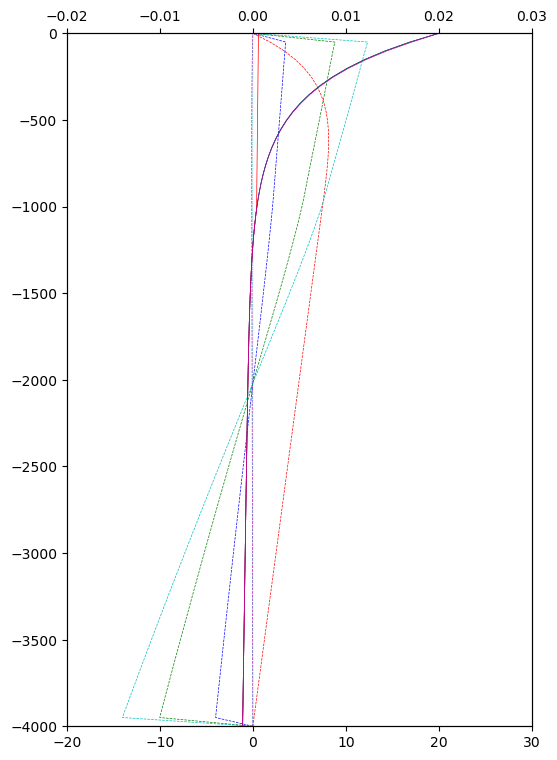

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.074 SV at depth -759.5 m
AMOC_abs: max = 14.074 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.115 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.115 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.115 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.084 SV at y = 3000.0 km, depth = -3848.1 m (indices 51, 3)
Pacific_b: max = -15.084 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.084 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


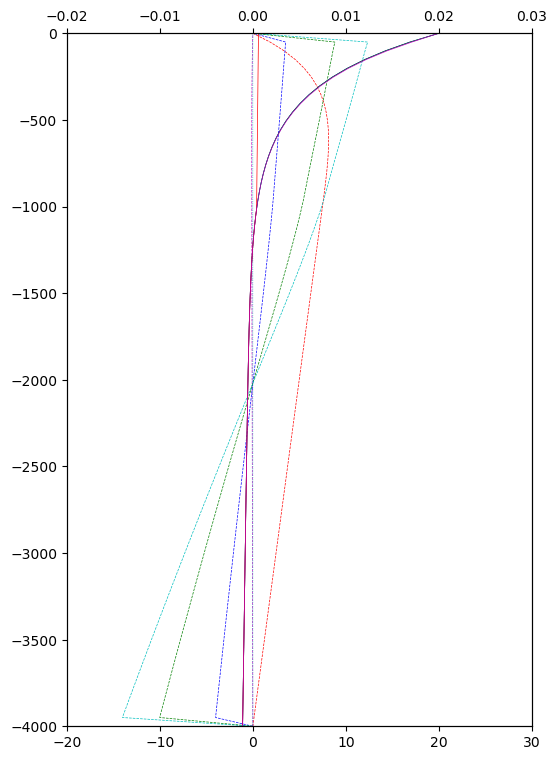

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.072 SV at depth -759.5 m
AMOC_abs: max = 14.072 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.116 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.116 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.116 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.084 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.084 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.084 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


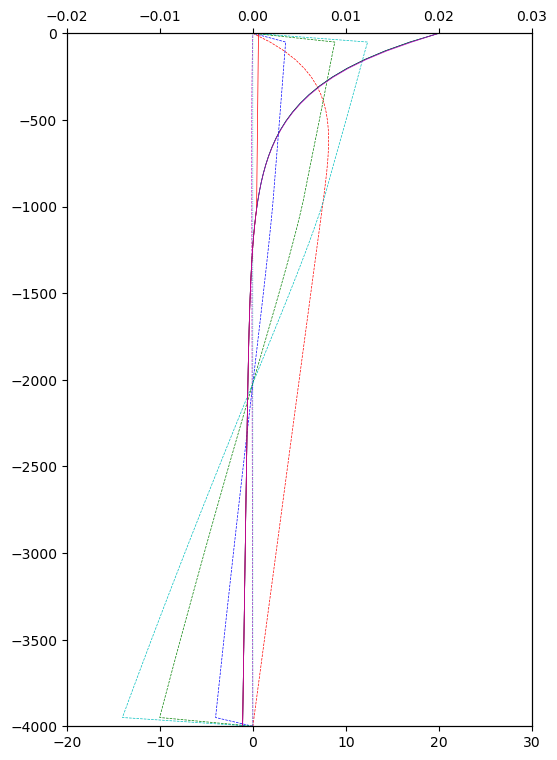

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.070 SV at depth -759.5 m
AMOC_abs: max = 14.070 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth -4000.0 m
Global_z: max = -15.117 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.117 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.117 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.085 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.085 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.085 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


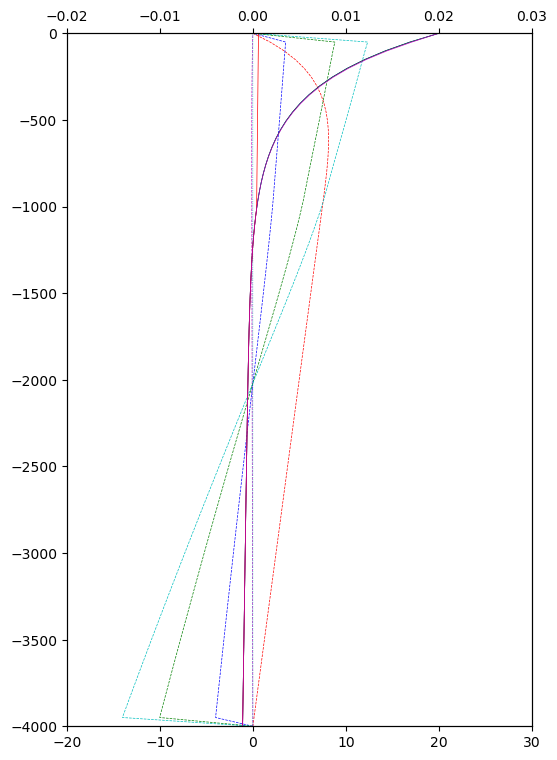

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.068 SV at depth -759.5 m
AMOC_abs: max = 14.068 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth -4000.0 m
Global_z: max = -15.117 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.117 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.117 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.085 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.085 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.085 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


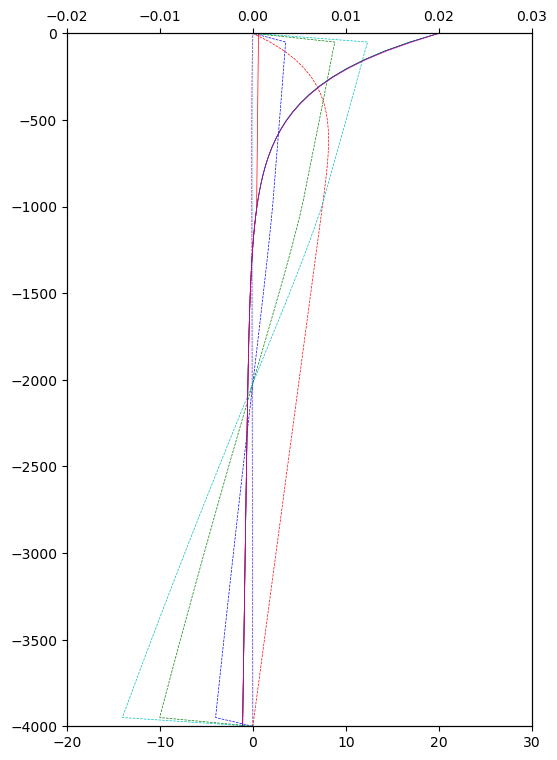

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.065 SV at depth -759.5 m
AMOC_abs: max = 14.065 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth -4000.0 m
Global_z: max = -15.118 SV at y = 3000.0 km, depth = -3848.1 m (indices 51, 3)
Pacific_z: max = -15.118 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.118 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.086 SV at y = 3000.0 km, depth = -3848.1 m (indices 51, 3)
Pacific_b: max = -15.086 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.086 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


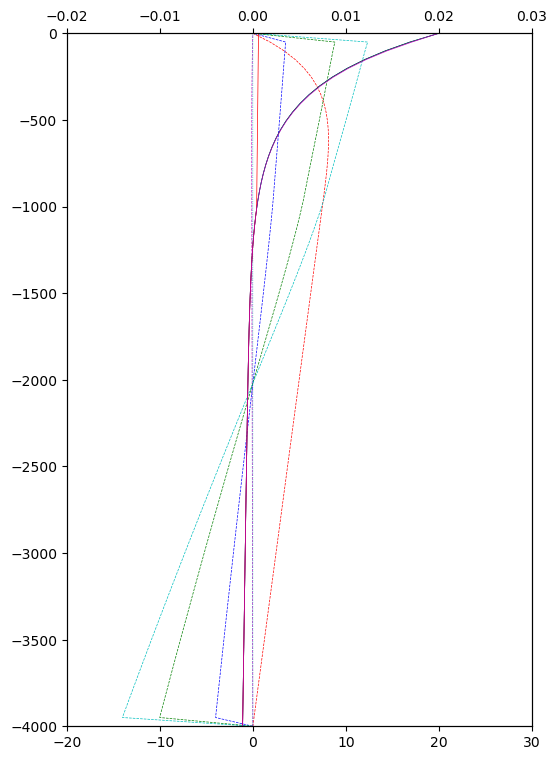

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.063 SV at depth -759.5 m
AMOC_abs: max = 14.063 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.118 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.118 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.118 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.086 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.086 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.086 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


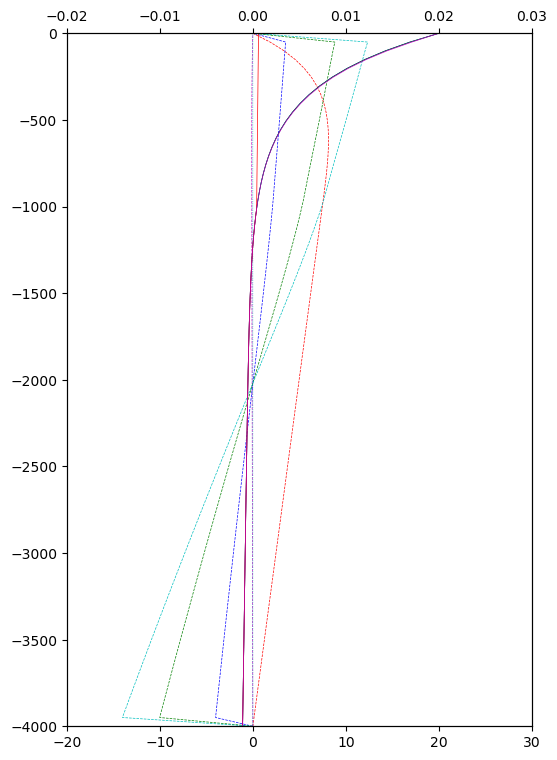

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.061 SV at depth -759.5 m
AMOC_abs: max = 14.061 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.119 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.119 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.119 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.087 SV at y = 3000.0 km, depth = -3848.1 m (indices 51, 3)
Pacific_b: max = -15.087 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.087 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


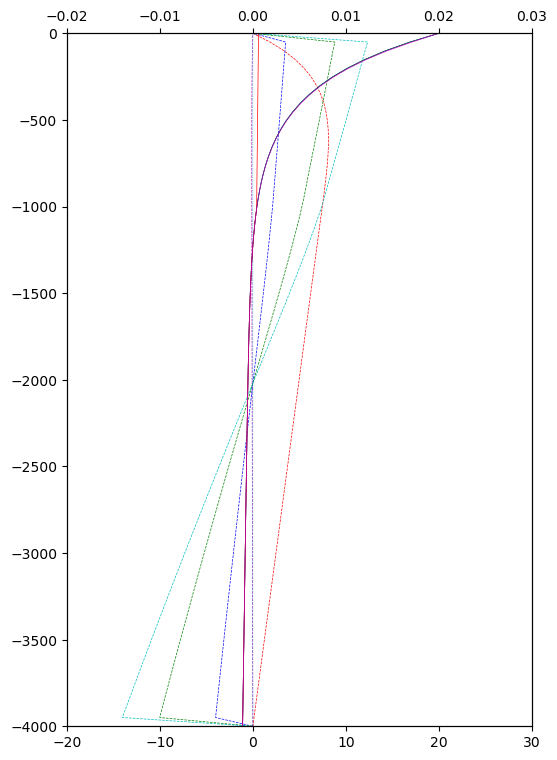

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.059 SV at depth -759.5 m
AMOC_abs: max = 14.059 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.119 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.119 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.119 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.087 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.087 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.087 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


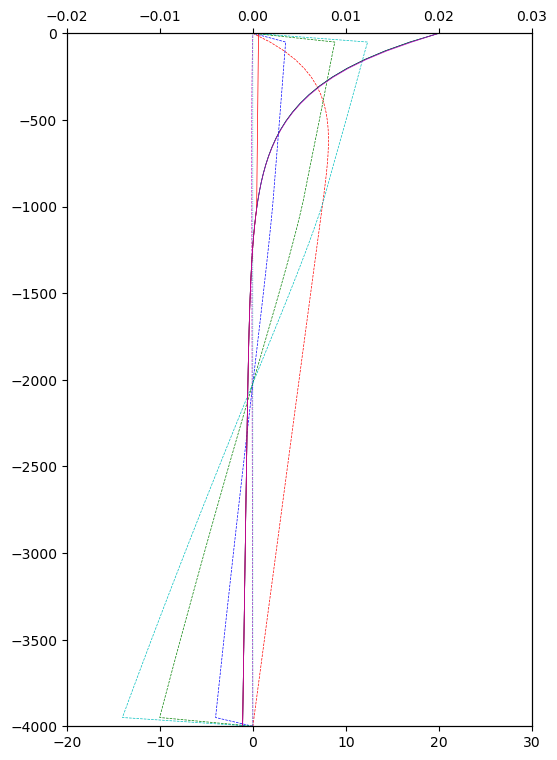

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.057 SV at depth -759.5 m
AMOC_abs: max = 14.057 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = -0.000 SV at depth -4000.0 m
Global_z: max = -15.120 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.120 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.120 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.088 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.088 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.088 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


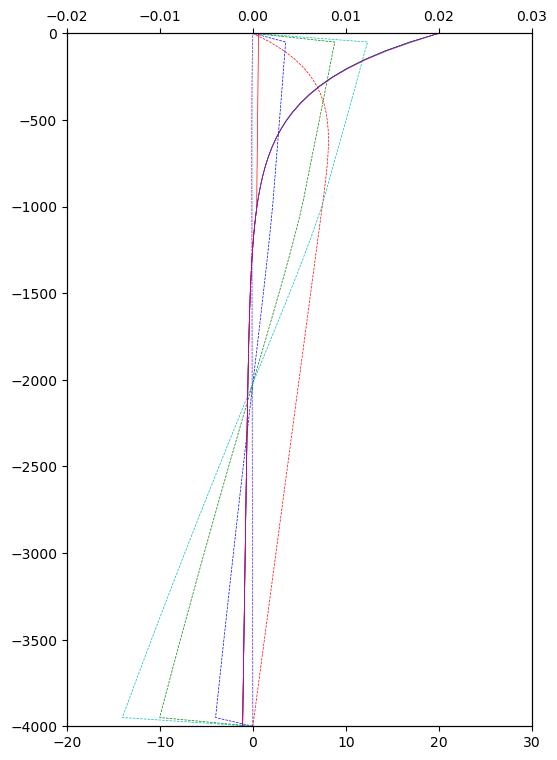

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.055 SV at depth -759.5 m
AMOC_abs: max = 14.055 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.120 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.120 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.120 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.089 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.089 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.089 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


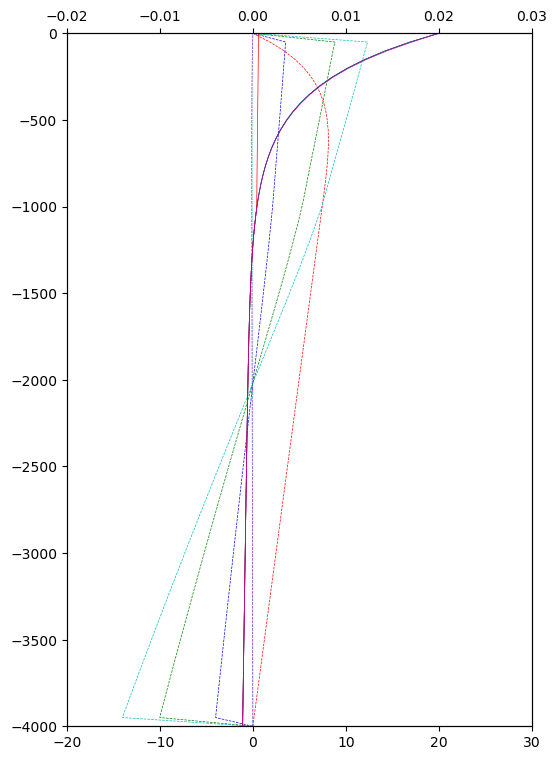

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.053 SV at depth -759.5 m
AMOC_abs: max = 14.053 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth -4000.0 m
Global_z: max = -15.121 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.121 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.121 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.089 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.089 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.089 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


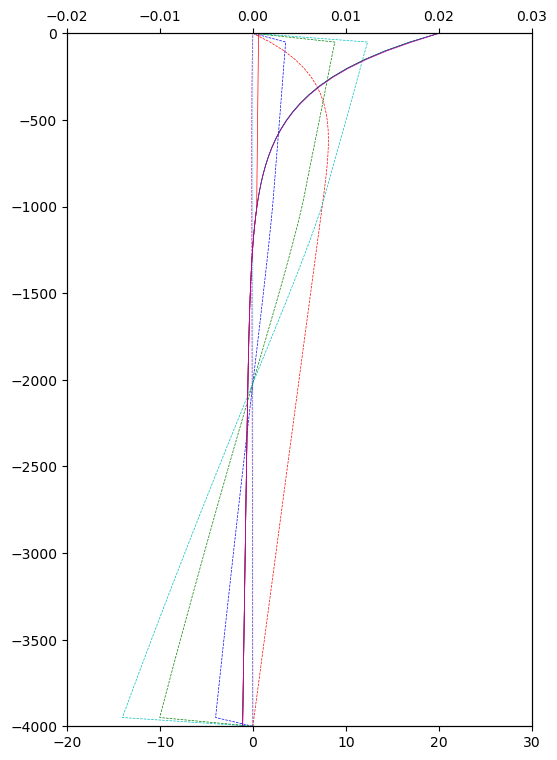

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.050 SV at depth -759.5 m
AMOC_abs: max = 14.050 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.121 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.121 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.121 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.089 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.089 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.089 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


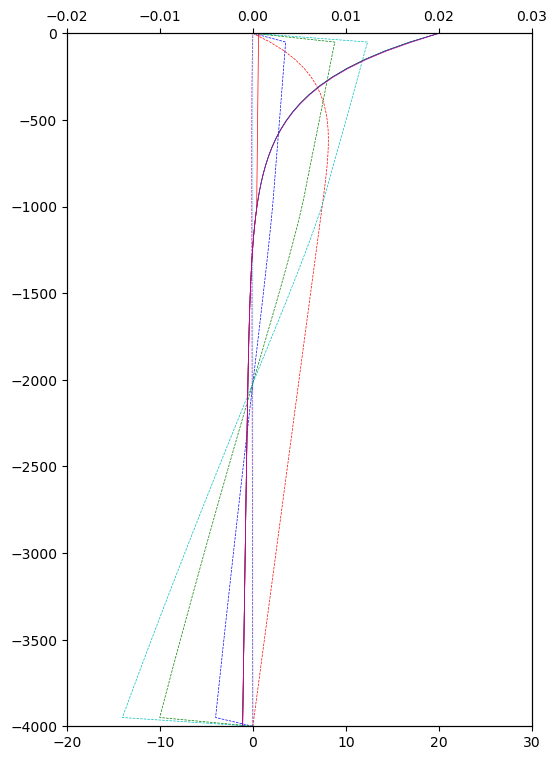

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.048 SV at depth -759.5 m
AMOC_abs: max = 14.048 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.122 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.122 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.122 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.090 SV at y = 3000.0 km, depth = -3848.1 m (indices 51, 3)
Pacific_b: max = -15.090 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.090 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


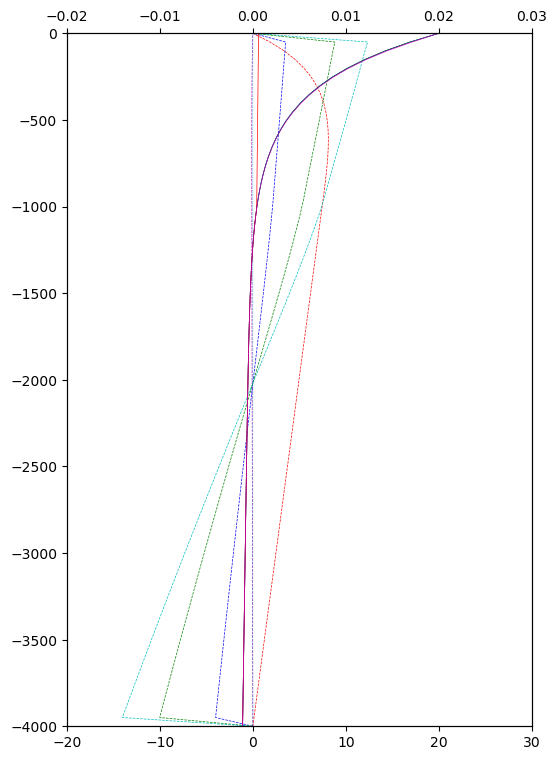

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.046 SV at depth -759.5 m
AMOC_abs: max = 14.046 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.122 SV at y = 3000.0 km, depth = -3848.1 m (indices 51, 3)
Pacific_z: max = -15.122 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.122 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.090 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.090 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.090 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


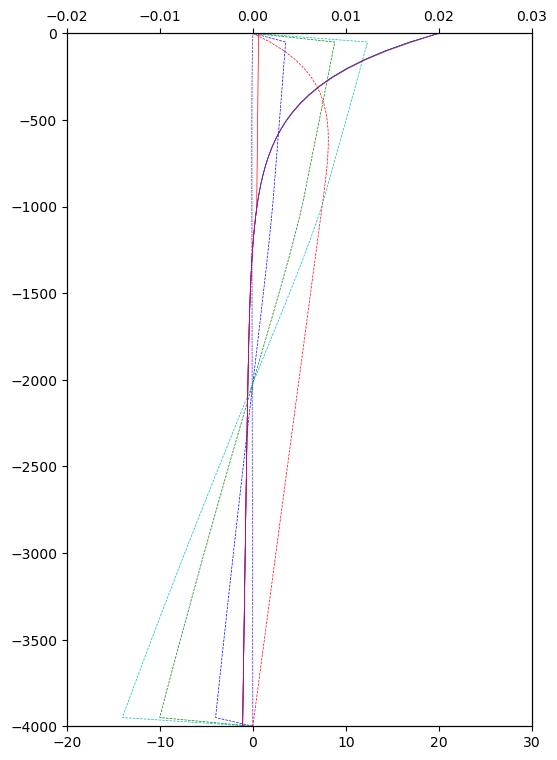

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.042 SV at depth -759.5 m
AMOC_abs: max = 14.042 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.122 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.122 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.122 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.090 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.090 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.090 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


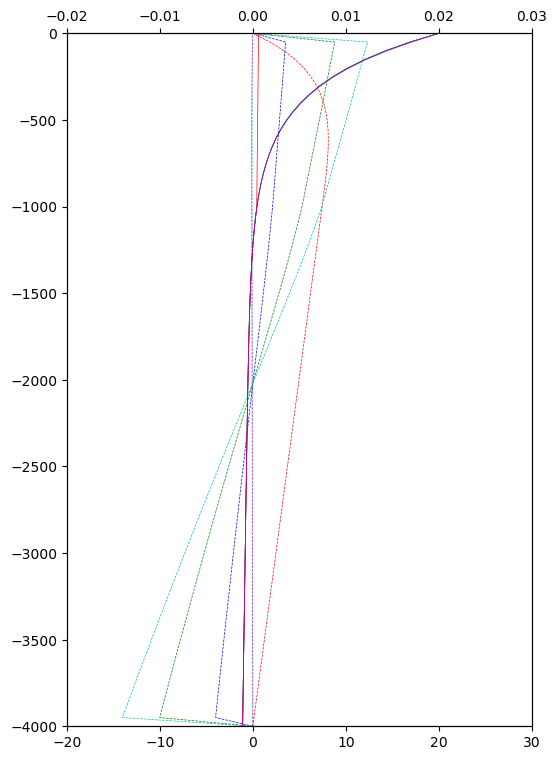

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.069 SV at depth -759.5 m
AMOC_abs: max = 14.069 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.117 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.117 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.117 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.085 SV at y = 3000.0 km, depth = -3848.1 m (indices 51, 3)
Pacific_b: max = -15.085 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.085 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


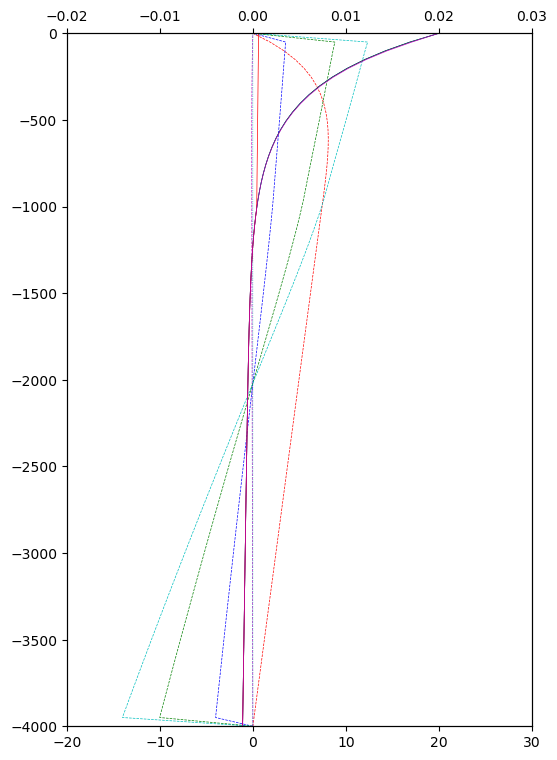

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.066 SV at depth -759.5 m
AMOC_abs: max = 14.066 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = -0.000 SV at depth -4000.0 m
Global_z: max = -15.118 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.118 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.118 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.086 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.086 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.086 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


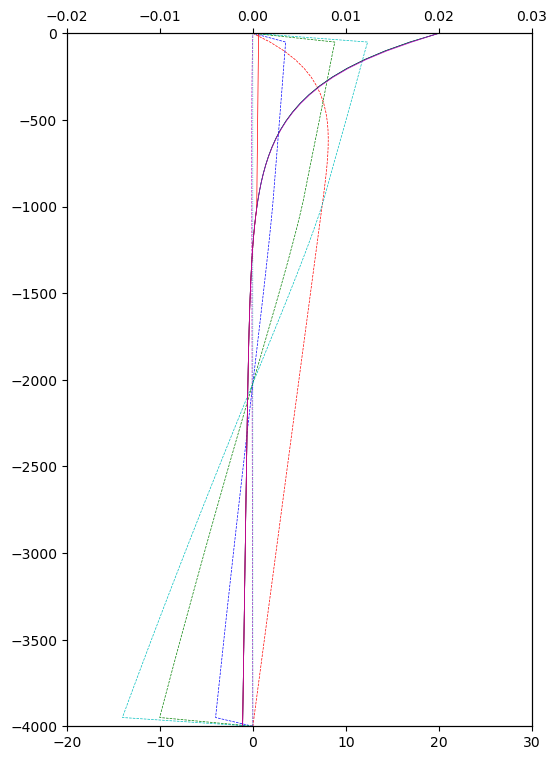

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.064 SV at depth -759.5 m
AMOC_abs: max = 14.064 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.118 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.118 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.118 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.086 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.086 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.086 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


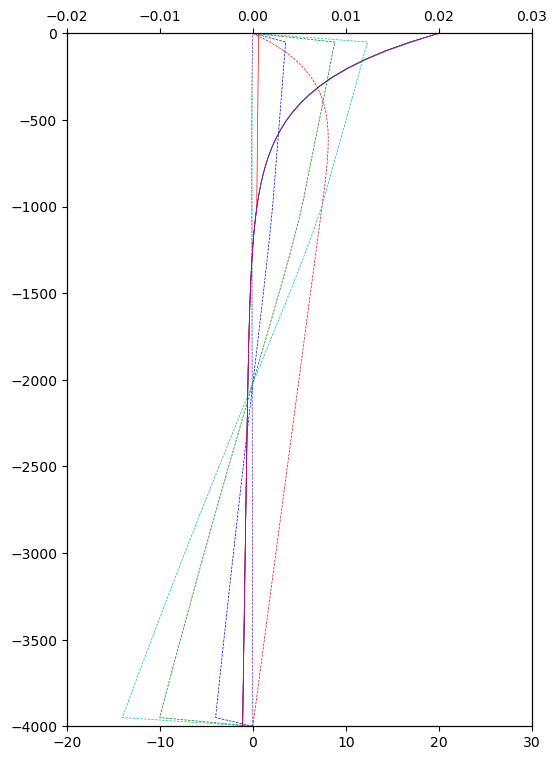

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.062 SV at depth -759.5 m
AMOC_abs: max = 14.062 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.119 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.119 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.119 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.087 SV at y = 3000.0 km, depth = -3848.1 m (indices 51, 3)
Pacific_b: max = -15.087 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.087 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


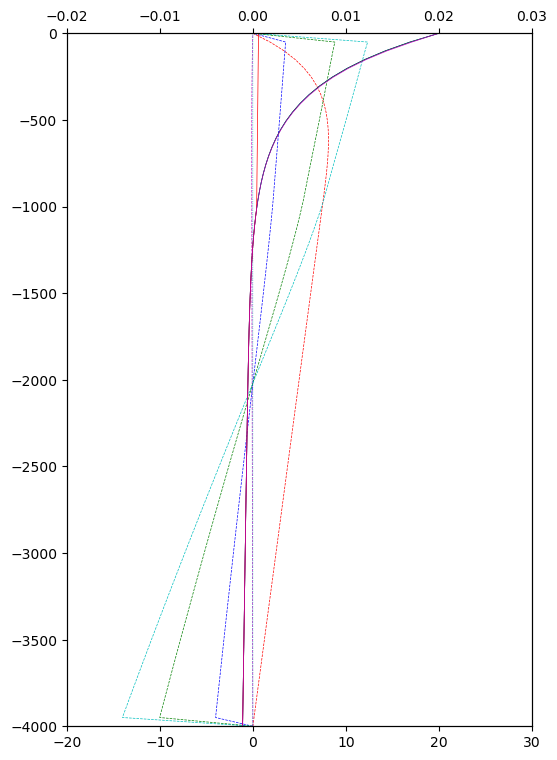

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.060 SV at depth -759.5 m
AMOC_abs: max = 14.060 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.119 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.119 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.119 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.087 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.087 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.087 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


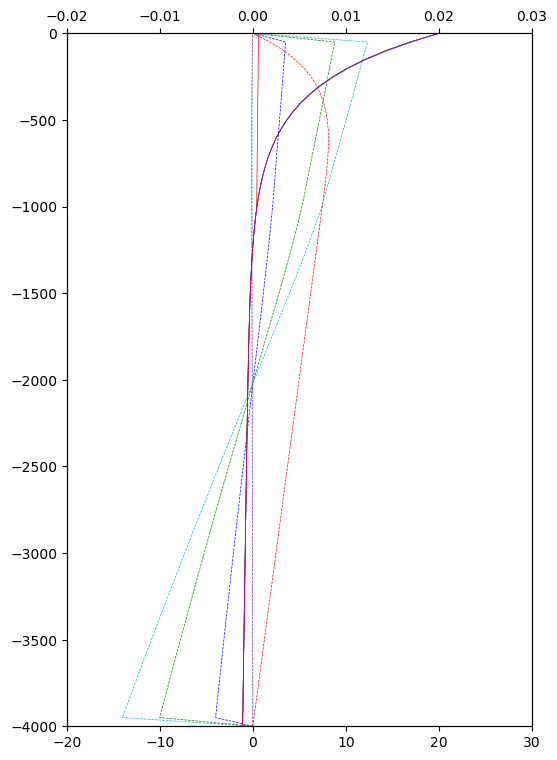

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.058 SV at depth -759.5 m
AMOC_abs: max = 14.058 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth -4000.0 m
Global_z: max = -15.120 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.120 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.120 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.088 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.088 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.088 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


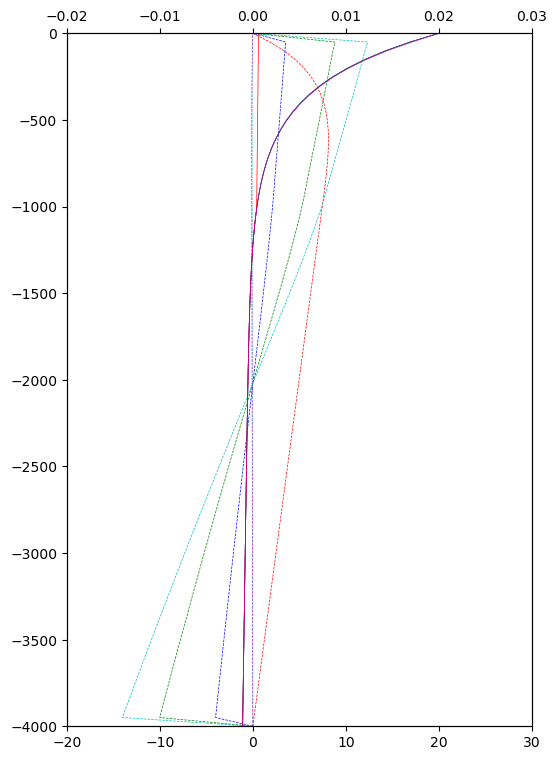

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.056 SV at depth -759.5 m
AMOC_abs: max = 14.056 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.120 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.120 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.120 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.089 SV at y = 3000.0 km, depth = -3848.1 m (indices 51, 3)
Pacific_b: max = -15.089 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.089 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


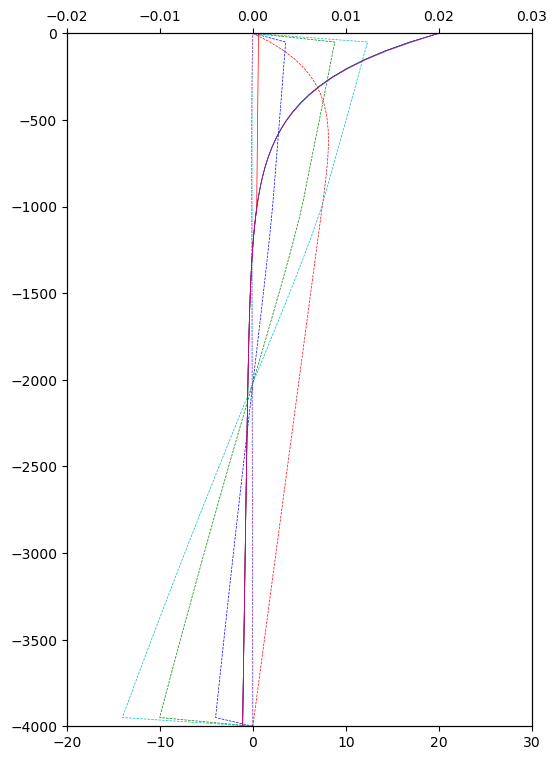

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.054 SV at depth -759.5 m
AMOC_abs: max = 14.054 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.121 SV at y = 3000.0 km, depth = -3848.1 m (indices 51, 3)
Pacific_z: max = -15.121 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.121 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.089 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.089 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.089 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


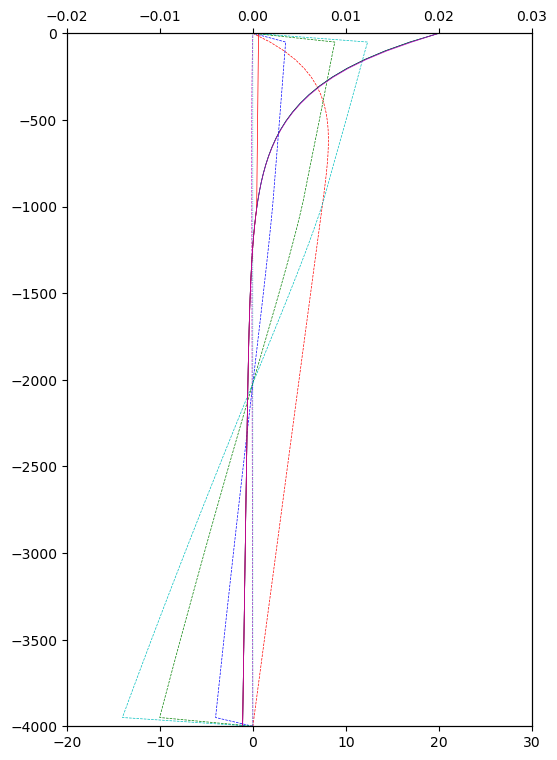

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.052 SV at depth -759.5 m
AMOC_abs: max = 14.052 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = -0.000 SV at depth -4000.0 m
Global_z: max = -15.122 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.122 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.122 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.090 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.090 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.090 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


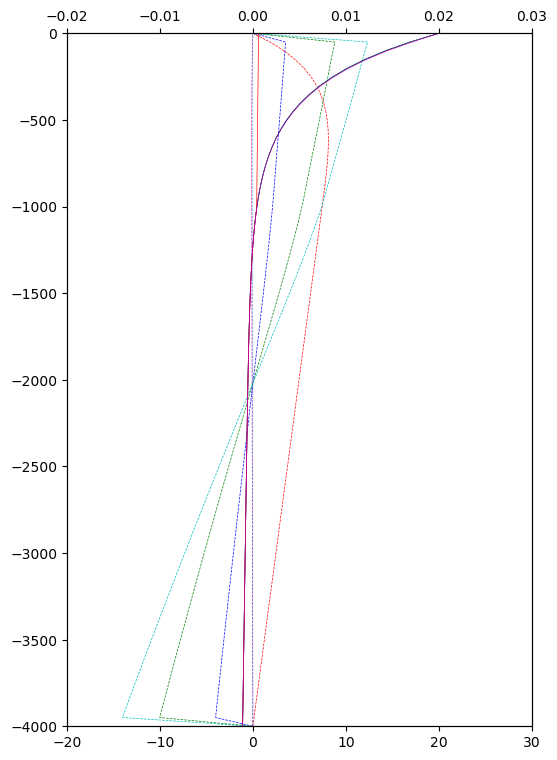

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.050 SV at depth -759.5 m
AMOC_abs: max = 14.050 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.122 SV at y = 3000.0 km, depth = -3848.1 m (indices 51, 3)
Pacific_z: max = -15.122 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.122 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.090 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.090 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.090 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


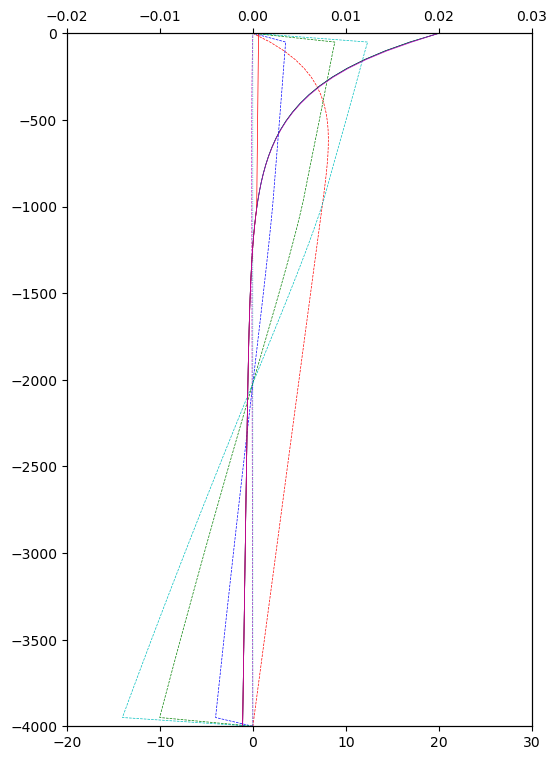

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.048 SV at depth -759.5 m
AMOC_abs: max = 14.048 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.123 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.123 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.123 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.091 SV at y = 3000.0 km, depth = -3848.1 m (indices 51, 3)
Pacific_b: max = -15.091 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.091 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


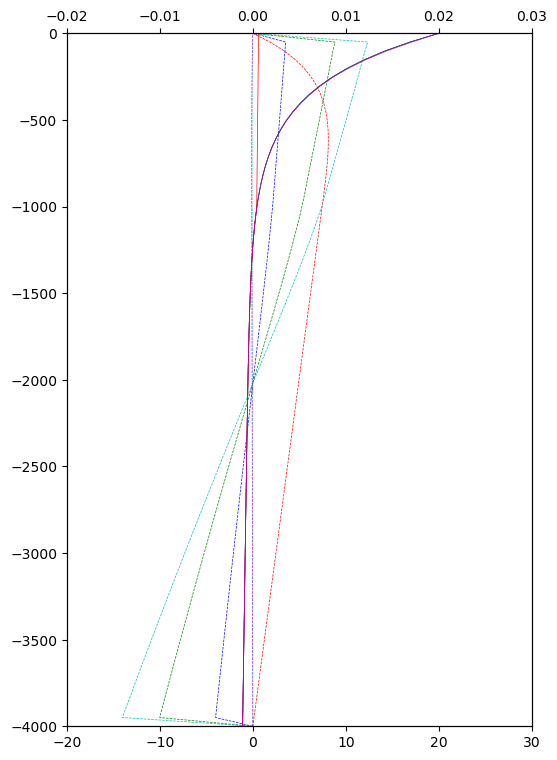

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.046 SV at depth -759.5 m
AMOC_abs: max = 14.046 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth -4000.0 m
Global_z: max = -15.123 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.123 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.123 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.091 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.091 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.091 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


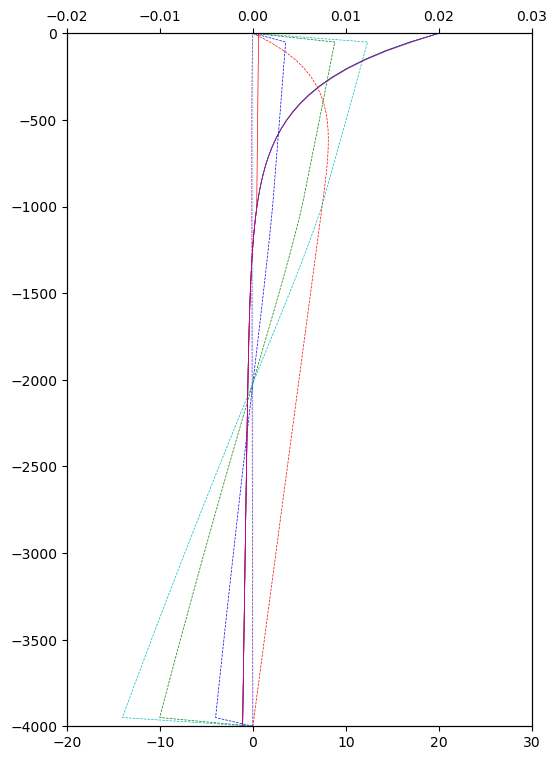

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.044 SV at depth -759.5 m
AMOC_abs: max = 14.044 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth -4000.0 m
Global_z: max = -15.124 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.124 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.124 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.092 SV at y = 3000.0 km, depth = -3848.1 m (indices 51, 3)
Pacific_b: max = -15.092 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.092 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


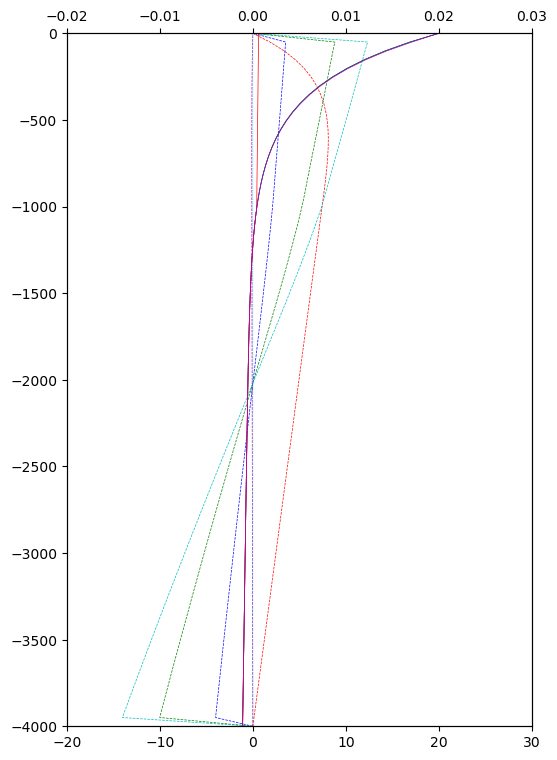

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.041 SV at depth -759.5 m
AMOC_abs: max = 14.041 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth -4000.0 m
Global_z: max = -15.124 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.124 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.124 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.092 SV at y = 3000.0 km, depth = -3848.1 m (indices 51, 3)
Pacific_b: max = -15.092 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.092 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


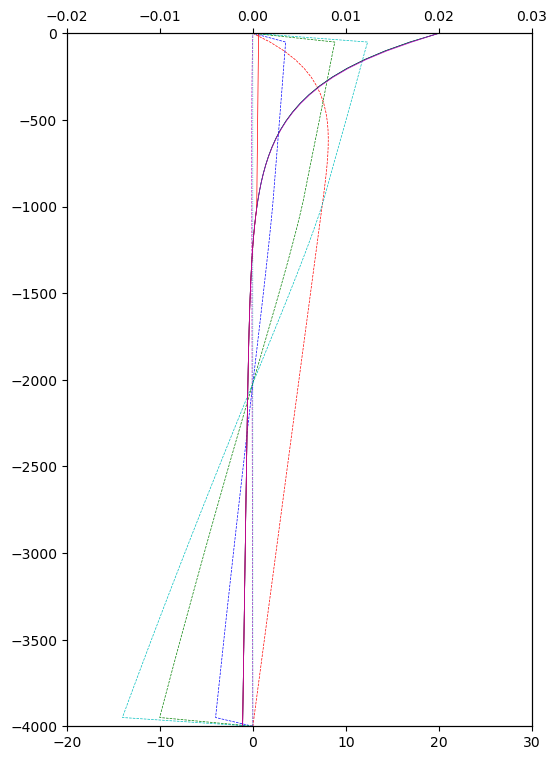

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.039 SV at depth -759.5 m
AMOC_abs: max = 14.039 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.125 SV at y = 3000.0 km, depth = -3848.1 m (indices 51, 3)
Pacific_z: max = -15.125 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.125 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.093 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.093 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.093 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


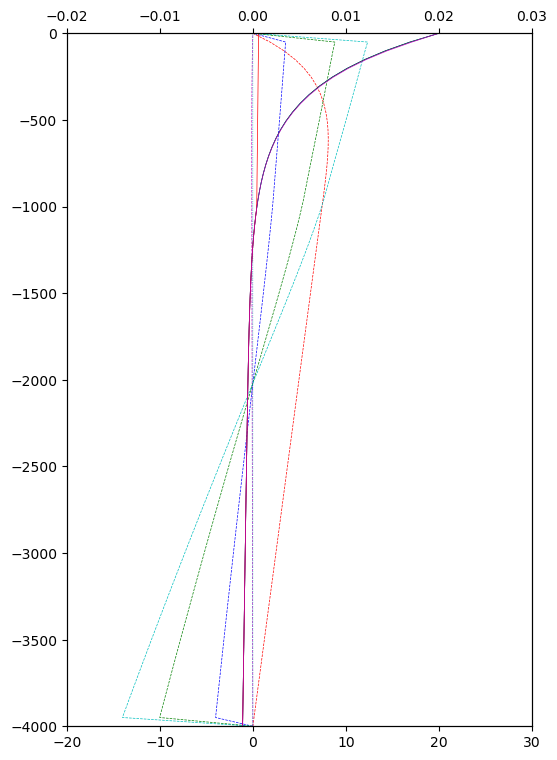

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.037 SV at depth -759.5 m
AMOC_abs: max = 14.037 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.126 SV at y = 3000.0 km, depth = -3848.1 m (indices 51, 3)
Pacific_z: max = -15.126 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.126 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.094 SV at y = 3000.0 km, depth = -3848.1 m (indices 51, 3)
Pacific_b: max = -15.094 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.094 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


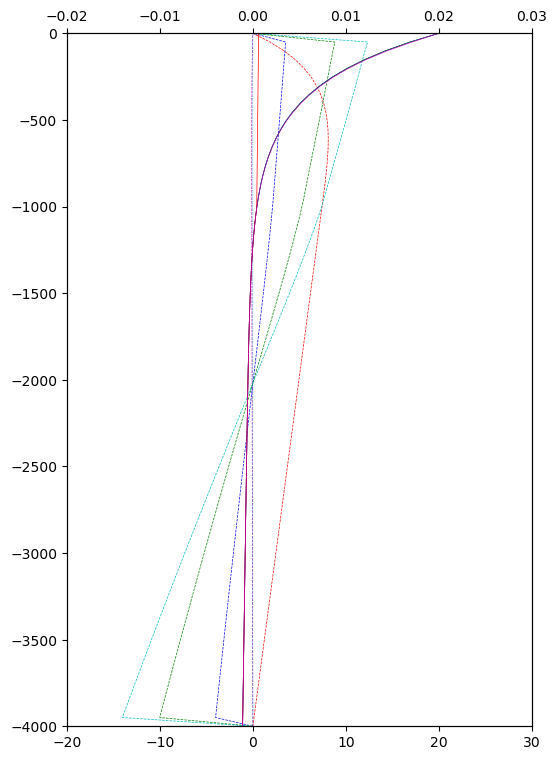

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.035 SV at depth -759.5 m
AMOC_abs: max = 14.035 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth -4000.0 m
Global_z: max = -15.126 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.126 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.126 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.094 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.094 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.094 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


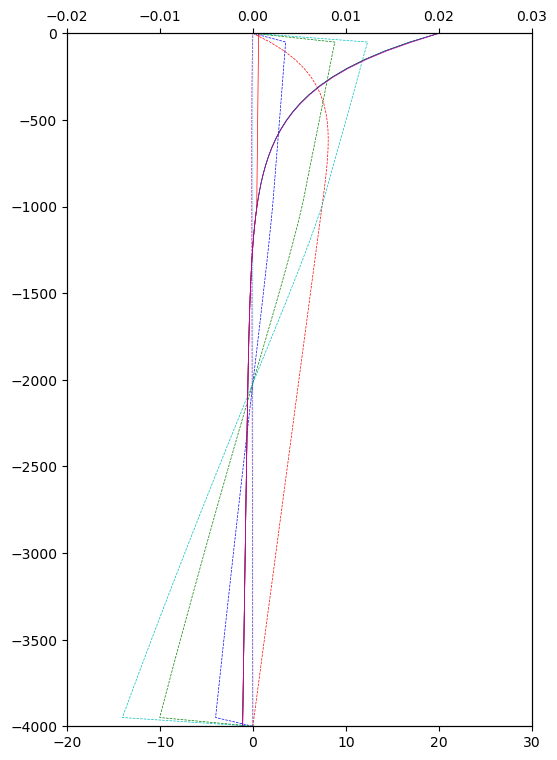

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.033 SV at depth -759.5 m
AMOC_abs: max = 14.033 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth -4000.0 m
Global_z: max = -15.127 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.127 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.127 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.095 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.095 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.095 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


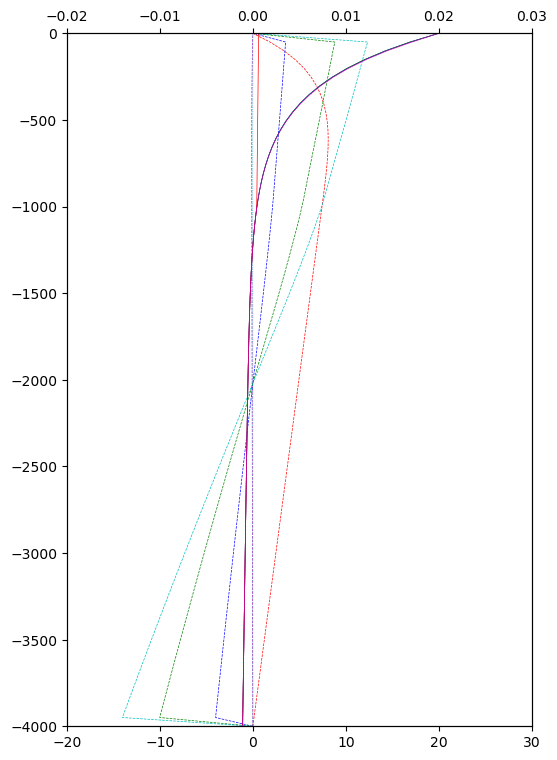

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.031 SV at depth -759.5 m
AMOC_abs: max = 14.031 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.127 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.127 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.127 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.095 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.095 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.095 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


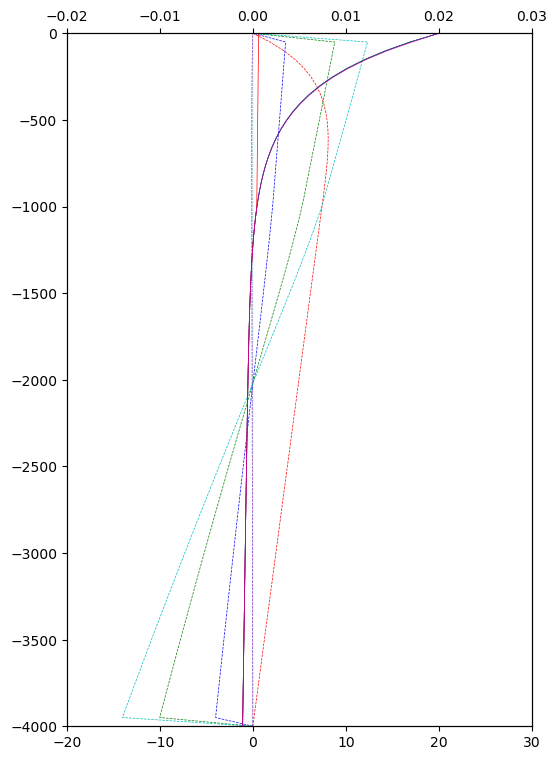

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.029 SV at depth -759.5 m
AMOC_abs: max = 14.029 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.128 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.128 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.128 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.096 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.096 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.096 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


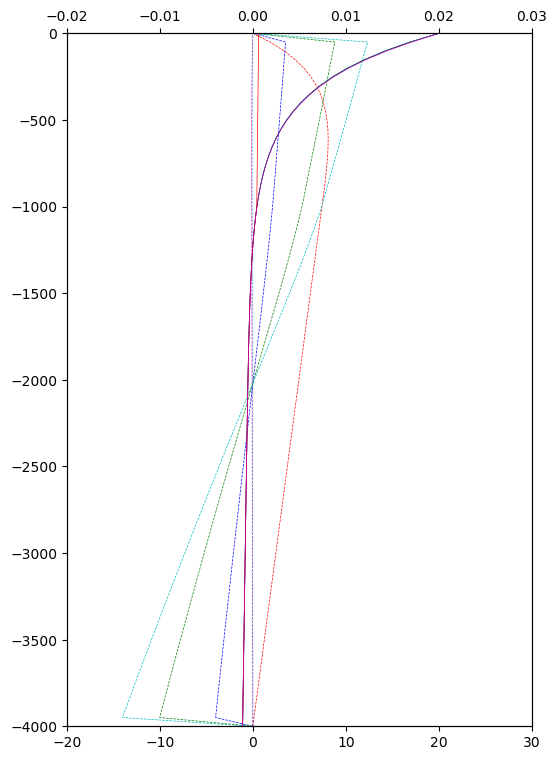

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.027 SV at depth -759.5 m
AMOC_abs: max = 14.027 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth 0.0 m
Global_z: max = -15.128 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.128 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.128 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.096 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Pacific_b: max = -15.096 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.096 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)


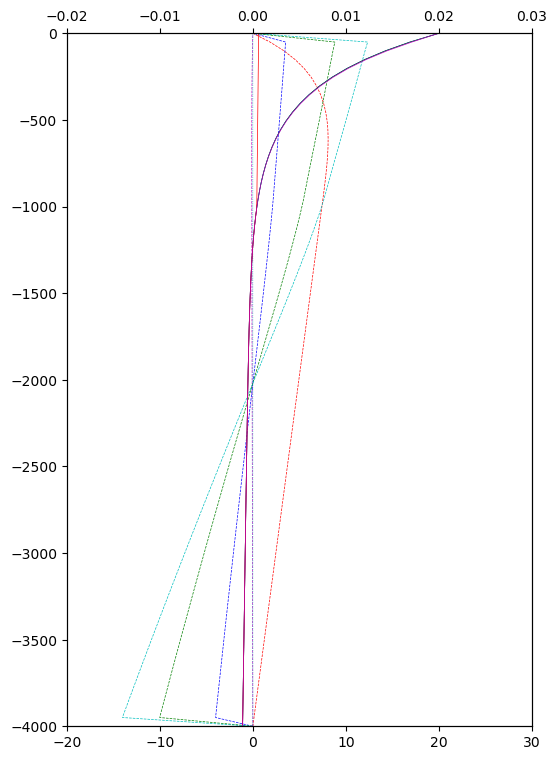

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_19140/52623707.py:522: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AMOC: max = 14.024 SV at depth -759.5 m
AMOC_abs: max = 14.024 SV at depth -759.5 m
PMOC: max = 0.007 SV at depth -101.3 m
ZOC: max = 0.000 SV at depth -4000.0 m
Global_z: max = -15.129 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Pacific_z: max = -15.129 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Atlantic_z: max = -15.129 SV at y = 3000.0 km, depth = -3848.1 m (indices 50, 3)
Global_b: max = -15.097 SV at y = 3000.0 km, depth = -3848.1 m (indices 51, 3)
Pacific_b: max = -15.097 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
Atlantic_b: max = -15.097 SV at y = 240.0 km, depth = -3848.1 m (indices 4, 3)
    bs_north_pac  bs_north  Global_z_max_SV  Global_z_max_y_km  \
0           0.02  0.000380        15.107963             3000.0   
1           0.02  0.000381        15.108539             3000.0   
2           0.02  0.000382        15.109116             3000.0   
3           0.02  0.000382        15.109691             3000.0   
4           0.02  0.000383      

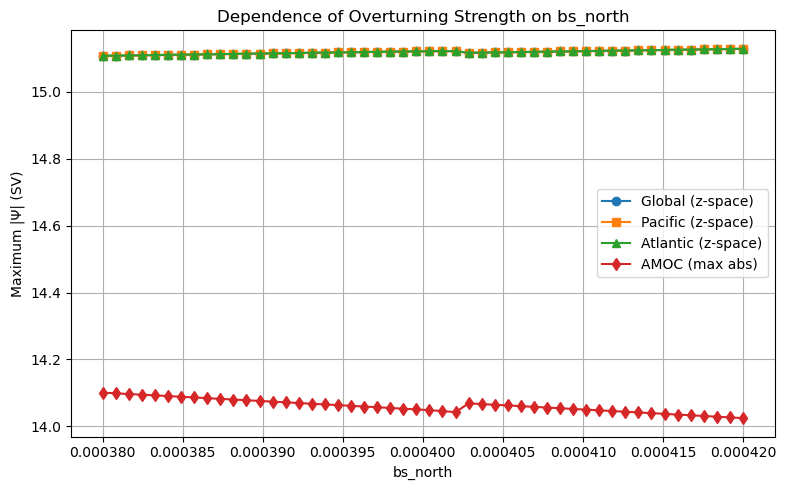

In [27]:
"""
Four-column MOC model, allowing for Northern sinking in the Pacific and the development of a PMOC.
"""

from pymoc.modules import Psi_Thermwind, Psi_SO, Column
from pymoc.plotting import Interpolate_channel, Interpolate_twocol
import numpy as np
from matplotlib import pyplot as plt

diag_file = None



#!!!
# bs_north_pac_vals = [0.0005,  0.005,  0.02] 
bs_north_pac_vals = [0.02] 

# NEW SECTION: define a sweep of bs_north values and a list to collect results
bs_north_sweep = [0.00034, 0.00035, 0.00036, 0.00037, 0.00038]
bs_north_sweep = np.linspace(0.00038, 0.00042, 50)

psi_sweep_results = []


for bs_north_pac in bs_north_pac_vals:
    # inner sweep over bs_north values
    for bs_north in bs_north_sweep:

        bs = 0.02;
        # the minimum surface buoyancy in the GCM in the North Atlantic is 3.5890e-04 (or 0.1795C)
        # original code set bs_north twice; we now use the loop variable bs_north
        #bs_north = 0.00036
        #bs_north = 0.00075
        bAABW = -0.0011  # x1
        # bAABW = -0.0044  # x4
        
        bbot = min(bAABW, bs_north, bs_north_pac)

        # S.O. surface boundary conditions and grid:
        y = np.asarray(np.linspace(0, 3.e6, 51))
        tau = 0.16
        offset = 0.0345*(1-np.cos(np.pi*(5.55e5-1.e5)/8e6));
        bs_SO = (0.0345*(1-np.cos(np.pi*(y-1.e5)/8e6))*(y>5.55e5)
              +(bAABW-offset)/5.55e5*np.maximum(0,5.55e5-y)+offset*(y<5.55e5));

        # time-stepping parameters:
        dt = 86400.*30.                               # time-step for vert. adv. diff. calc.
        MOC_up_iters = int(np.floor(2.*360*86400/dt)) # multiplier for MOC time-step (MOC is updated every MOC_up_iters time steps)
        plot_iters = int(np.ceil(500*360*86400/dt))   # plotting frequency (in iterations)
        total_iters = int(np.ceil(4000*360*86400/dt)) # total number of timesteps

        # Effective diffusivity profile          #original
        def kappaeff(z): # effective diffusivity profile with tapering in BBL
                return 1.0*( 1e-4*(1.1-np.tanh(np.maximum(z+2000.,0)/1000. + np.minimum(z+2000.,0)/1300.))
                        *(1.-np.maximum(-4000.-z+600.,0.)/600.)**2 )

        # def kappaeff(z): # effective diffusivity profile with tapering in BBL
        #         return 1.0*( 3e-5*(1.1-np.tanh(np.maximum(z+2000.,0)/1000. + np.minimum(z+2000.,0)/1300.))
        #                 *(1.-np.maximum(-4000.-z+600.,0.)/600.)**2 )
            
        # kappa = 3e-5 based on the quasi-constant (in the vertical) diffusivity inferred by Kunze (2017)
        # kappaeff = 3e-5 

        
        # a κ based on the bulk basin-wide estimate of Lumpkin and Speer (2007)
        

        A_Atl = 7e13#6e13  
        A_north_atl = 5.5e12
        # A_Pac = 1.7e14 #1.44e14      #old
        
        A_Pac = 1.7e14 - 5.5e12            #new
        A_north_pac = 5.5e12 #new 5.5e12
        
        Lx = 1.3e+07  #(length of the channel)
        Latl = 6./21.*Lx;
        Lpac = 15./21.*Lx;
        K = 1800.
        N2min = 2e-7
        
        z = np.asarray(np.linspace(-4000, 0, 80))
        
        # create initial guess for buoyancy profile in the Atl
        def b_Atl(z): return bs*np.exp(z/300.)+z/z[0]*bbot
        #def b_Atl(z): return 0.3*bs+z/z[0]*(bbot-0.3*bs)
        def b_Pac(z): return bs*np.exp(z/300.)+z/z[0]*bbot

        # create N.A. overturning model instance
        AMOC = Psi_Thermwind(z=z, b1=b_Atl, b2=0.01*b_Atl(z))
        # and solve for initial overturning streamfunction:
        AMOC.solve()
        # map North Atlantic overturning to isopycnal space:
        [Psi_iso_Atl, Psi_iso_N] = AMOC.Psibz()
        ####
        
        # create Pacific overturning model instance (PMOC) for North Pacific sinking
        PMOC = Psi_Thermwind(z=z, b1=b_Pac, b2=0.01*b_Pac(z))
        
        PMOC.solve()
        [Psi_iso_Pac, Psi_iso_NPac] = PMOC.Psibz()
        
        # create interbasin zonal overturning model instance
        ZOC = Psi_Thermwind(z=z, b1=b_Atl, b2=b_Pac, f=1e-4)
        # and solve for initial overturning streamfunction:
        ZOC.solve()
        # map inter-basin overturning to isopycnal space:
        [Psi_zonal_Atl, Psi_zonal_Pac] = ZOC.Psibz()
        
        # create S.O. overturning model instance for Atlantic sector
        SO_Atl = Psi_SO(z=z, y=y, b=b_Atl(z), bs=bs_SO, tau=tau, L=Latl, KGM=K)
        SO_Atl.solve()
        
        # create S.O. overturning model instance for Pacific sector
        SO_Pac = Psi_SO(z=z, y=y, b=b_Pac(z), bs=bs_SO, tau=tau, L=Lpac, KGM=K)
        SO_Pac.solve()

        
        
        # create adv-diff column model instance for Atl
        Atl = Column(z=z, kappa=kappaeff, b=b_Atl, bs=bs, bbot=bbot, Area=A_Atl, N2min=N2min)
        # create adv-diff column model instance for northern sinking region (Atlantic)
        north = Column(z=z, kappa=kappaeff, b=b_Atl, bs=bs_north, bbot=bbot, Area=A_north_atl, N2min=N2min)
        # create adv-diff column model instance for Pac
        Pac = Column(z=z, kappa=kappaeff, b=b_Pac, bs=bs, bbot=bbot, Area=A_Pac, N2min=N2min)
        # create adv-diff column model instance for northern Pacific sinking region
        ####### !!!!
        north_Pac = Column(z=z, kappa=kappaeff, b=b_Pac, bs=bs_north_pac, bbot=bbot, Area=A_north_pac, N2min=N2min)
        
        # Create figure:
        fig = plt.figure(figsize=(6,9))
        ax1 = fig.add_subplot(111)
        ax2 = ax1.twiny()
        plt.ylim((-4e3,0))
        ax1.set_xlim((-20,30))
        ax2.set_xlim((-0.02,0.030))
        
        # loop to iteratively find equilibrium solution
        for ii in range(0, total_iters):    
           # update buoyancy profile
           # using isopycnal overturning:
           wA_Atl = (Psi_iso_Atl + Psi_zonal_Atl - SO_Atl.Psi) * 1e6
           wAN = -Psi_iso_N * 1e6
           # Include Pacific isopycnal overturning contribution and SO residual
           wA_Pac = (-Psi_zonal_Pac - SO_Pac.Psi + Psi_iso_Pac) * 1e6
           wA_NPac = -Psi_iso_NPac * 1e6
        
           Atl.timestep(wA=wA_Atl, dt=dt)
           north.timestep(wA=wAN, dt=dt, do_conv=True)
           Pac.timestep(wA=wA_Pac, dt=dt)
           north_Pac.timestep(wA=wA_NPac, dt=dt, do_conv=True)
           
           if ii % MOC_up_iters == 0:
              # update overturning streamfunction (can be done less frequently)
              AMOC.update(b1=Atl.b, b2=north.b)
              AMOC.solve()
              [Psi_iso_Atl, Psi_iso_N] = AMOC.Psibz()
        
              PMOC.update(b1=Pac.b, b2=north_Pac.b)
              PMOC.solve()
              [Psi_iso_Pac, Psi_iso_NPac] = PMOC.Psibz()
        
              ZOC.update(b1=Atl.b, b2=Pac.b)
              ZOC.solve()
              [Psi_zonal_Atl, Psi_zonal_Pac] = ZOC.Psibz()
        
              SO_Atl.update(b=Atl.b)
              SO_Atl.solve()
              SO_Pac.update(b=Pac.b)
              SO_Pac.solve()
             
           if ii % plot_iters == 0:
              # Plot current state:
              ax1.plot(AMOC.Psi, AMOC.z,'--r', linewidth=0.5)
              ax1.plot(PMOC.Psi, PMOC.z,'--m', linewidth=0.5)         # Pacific overturning (PMOC)
              ax1.plot(ZOC.Psi, ZOC.z, ':c', linewidth=0.5)
              ax1.plot(SO_Atl.Psi-ZOC.Psi, SO_Atl.z, '--b', linewidth=0.5)
              ax1.plot(SO_Pac.Psi+ZOC.Psi, SO_Pac.z, '--g', linewidth=0.5)
              ax1.plot(SO_Atl.Psi+SO_Pac.Psi, z, '--c', linewidth=0.5)
              ax2.plot(Atl.b, Atl.z, '-b', linewidth=0.5)
              ax2.plot(Pac.b, Pac.z, '-g', linewidth=0.5)
              ax2.plot(north.b, north.z, '-r', linewidth=0.5)
              ax2.plot(north_Pac.b, north_Pac.z, '-m', linewidth=0.5)  # northern Pacific buoyancy
              plt.pause(0.01)
              print ( "t=", round(ii*dt/86400/360), "years")
         
        ax1.plot(AMOC.Psi, AMOC.z,'--r', linewidth=1.5)
        ax1.plot(PMOC.Psi, PMOC.z,'--m', linewidth=1.5)
        ax1.plot(ZOC.Psi, ZOC.z, ':c', linewidth=1.5)
        ax1.plot(SO_Atl.Psi-ZOC.Psi, SO_Atl.z, '--b', linewidth=1.5)
        ax1.plot(SO_Pac.Psi+ZOC.Psi, SO_Pac.z, '--g', linewidth=1.5)
        ax1.plot(SO_Atl.Psi+SO_Pac.Psi, z, '--c', linewidth=1.5)
        ax2.plot(Atl.b, Atl.z, '-b', linewidth=1.5)
        ax2.plot(Pac.b, Pac.z, '-g', linewidth=1.5)
        ax2.plot(north.b, north.z, '-r', linewidth=1.5)
        ax2.plot(north_Pac.b, north_Pac.z, '-m', linewidth=1.5)
        
        # Write out diagnostics (if diag file name is provided):
        if diag_file is not None:
           np.savez(diag_file, b_Atl=Atl.b, b_Pac=Pac.b, b_north=north.b, b_north_Pac=north_Pac.b,
                    Psi_SO_Atl=SO_Atl.Psi, Psi_SO_Pac=SO_Pac.Psi,
                    Psi_ZOC=ZOC.Psi, Psib_ZOC=ZOC.Psib(), bgrid_ZOC=ZOC.bgrid,
                    Psi_AMOC=AMOC.Psi, Psib_AMOC=AMOC.Psib(), bgrid_AMOC=AMOC.bgrid,
                    Psi_PMOC=PMOC.Psi, Psib_PMOC=PMOC.Psib(), bgrid_PMOC=PMOC.bgrid)
        
        # Plotting 
        
        blevs = np.array([-0.004,-0.002,0.0,0.004,0.01,0.018])
        plevs = np.arange(-21.,23.,2.0)
        nb = 500;
        
        b_basin = (A_Atl*Atl.b + A_Pac*Pac.b) / (A_Atl + A_Pac);
        
        #!!!!!
        b_north = (A_north_atl*north.b + A_north_pac*north_Pac.b) / (A_north_atl + A_north_pac);
        
        # Compute total SO residual overturning by first interpolating circulation 
        # in both sectors to mean buoyancy profile values and then summing (at constant b).
        PsiSO = (np.interp(b_basin, Atl.b, SO_Atl.Psi)
              + np.interp(b_basin, Pac.b, SO_Pac.Psi));
        
        AMOC_bbasin = np.interp(b_basin, AMOC.bgrid, AMOC.Psib(nb=nb));
        
        PMOC_bbasin = np.interp(b_basin, PMOC.bgrid, PMOC.Psib(nb=nb));   # new 
        # this is to Plot adiabatic overturning only:
        
        PsiSO_bgrid = (np.interp(AMOC.bgrid, Atl.b, SO_Atl.Psi)        #original version
                    + np.interp(AMOC.bgrid, Pac.b, SO_Pac.Psi));
        
        # PsiSO_bgrid = (np.interp(AMOC.bgrid, Atl.b, SO_Atl.Psi)
        #             + np.interp(AMOC.bgrid, Pac.b, SO_Pac.Psi)
        #             + np.interp(PMOC.bgrid, Atl.b, SO_Atl.Psi)
        #             + np.interp(PMOC.bgrid, Pac.b, SO_Pac.Psi)) ;
        
        l = y[-1];
        
        bs = 1.*bs_SO
        bn = 1.*b_basin
        bs[-1] = 1.*bn[-1]; # if bs is tiny bit warmer there is a zero slope point at the surface which makes the interpolation fail...
        
        # first interpolate buoyancy in channel along constant-slope isopycnals: 
        bint = Interpolate_channel(y=y, z=z, bs=bs, bn=bn)
        bsouth = bint.gridit()
        # buoyancy in the basin is all the same:
        lbasin = 11000.
        ltrans = 1500.
        lnorth = 400.
        lchannel = l/1e3
        ybasin = np.linspace(0, lbasin, 60) + lchannel;
        bbasin = np.tile(b_basin, (len(ybasin), 1))
        bAtl = np.tile(Atl.b, (len(ybasin), 1))
        bPac = np.tile(Pac.b, (len(ybasin), 1))

        
        # interpolate buoyancy in northern transition region:
        ytrans = np.linspace(ltrans/20., ltrans, 20) + lchannel + lbasin;
        bn = b_north.copy();
        bn[0] = b_basin[0]; # Notice that the interpolation procedure assumes that the bottom
        #buoyancies in both columns match - which may not be exactly the case depending
        # on when in the time-step data is saved 
        bint = Interpolate_twocol(y=ytrans*1000.-ytrans[0]*1000., z=z, bs=Atl.b, bn=bn)
        btrans = bint.gridit()
        # finally set buyancy in northern deep water formation region:
        ynorth = np.linspace(lnorth/20., lnorth, 20) + lchannel + lbasin + ltrans;
        bnorth = np.tile(bn, (len(ynorth), 1))
        bnorth_atl = np.tile(bn, (len(ynorth), 1))
        bnorth_pac = np.tile(bn, (len(ynorth), 1))
        # now stick it all together:
        ynew = np.concatenate((y/1e3, ybasin, ytrans, ynorth))
        bnew = np.concatenate((bsouth, bbasin, btrans, bnorth))
        bnew_Atl = np.concatenate((bsouth, bAtl, btrans, bnorth_atl))
        bnew_Pac = np.concatenate((bsouth, bPac, btrans, bnorth_pac))    ## new
        
        # Compute z-coordinate and residual overturning streamfunction at all latitudes:
        psiarray_b = np.zeros((len(ynew), len(z))) # overturning in b-coordinates
        psiarray_b_Atl = np.zeros((len(ynew), len(z))) # overturning in b-coordinates
        psiarray_b_Pac = np.zeros((len(ynew), len(z))) # overturning in b-coordinates
        psiarray_Atl = np.zeros((len(ynew), len(z))) # "residual" overturning in ATl.
        psiarray_Pac = np.zeros((len(ynew), len(z))) # "residual" overturning in Pac.
        psiarray_z = np.zeros((len(ynew), len(z)))  # z-space, "eulerian" overturning
        psiarray_z_Atl = np.zeros((len(ynew), len(z)))  # z-space, "eulerian" overturning
        psiarray_z_Pac = np.zeros((len(ynew), len(z)))  # z-space, "eulerian" overturning
        
        # for iy in range(1, len(y)):
        #     psiarray_z[iy,:] = np.interp(bnew[iy,:], b_basin, (SO_Atl.Psi + SO_Pac.Psi) )
            
        #     psiarray_z_Atl[iy,:] = np.interp(bnew[iy,:], b_basin, SO_Atl.Psi)
        #     psiarray_z_Pac[iy,:] = np.interp(bnew[iy,:], b_basin, SO_Pac.Psi)
        
        #     psiarray_b[iy, b_basin < bs_SO[iy]] = PsiSO[b_basin < bs_SO[iy]]
            
        #     psiarray_Atl[iy, b_basin < bs_SO[iy]] = np.interp(b_basin[b_basin < bs_SO[iy]], b_basin, SO_Atl.Psi)[:]
        #     psiarray_b_Atl[iy, b_basin < bs_SO[iy]] = psiarray_Atl[iy, b_basin < bs_SO[iy]]
            
        #     psiarray_Pac[iy, b_basin < bs_SO[iy]] = np.interp(b_basin[b_basin < bs_SO[iy]], b_basin, SO_Pac.Psi)[:]
        #     psiarray_b_Pac[iy, b_basin < bs_SO[iy]] = psiarray_Pac[iy, b_basin < bs_SO[iy]]

        for iy in range(1,len(y)):
            # in the channel, interpolate PsiSO onto local isopycnal depth:
            psiarray_z[iy,:]=np.interp(bnew[iy,:],b_basin,SO_Atl.Psi+SO_Pac.Psi)
            psiarray_z_Atl[iy,:]=psiarray_z[iy,:]
            psiarray_z_Pac[iy,:]=psiarray_z[iy,:]
            psiarray_b[iy,b_basin<bs_SO[iy]]=PsiSO[b_basin<bs_SO[iy]]
            psiarray_Atl[iy,:]=np.interp(bnew[iy,:],b_basin,PsiSO);    
            psiarray_b_Atl[iy,:]=psiarray_b[iy,:];    
            psiarray_Pac[iy,:]=np.interp(bnew[iy,:],b_basin,PsiSO)   
            psiarray_b_Pac[iy,:]=psiarray_b[iy,:]; 

            



        for iy in range(len(y), len(y)+len(ybasin)):
            psiarray_z[iy,:] = ((ynew[iy]-lchannel)*(AMOC.Psi + PMOC.Psi)
                                + (lchannel + lbasin - ynew[iy])*(SO_Atl.Psi + SO_Pac.Psi))/lbasin
        
            psiarray_z_Atl[iy,:] = ((ynew[iy]-lchannel)*AMOC.Psi
                                     + (lchannel + lbasin - ynew[iy])*(SO_Atl.Psi - ZOC.Psi))/lbasin
        
            psiarray_z_Pac[iy,:] = ((ynew[iy]-lchannel)*PMOC.Psi
                                     + (lchannel + lbasin - ynew[iy])*(SO_Pac.Psi + ZOC.Psi))/lbasin
        
            psiarray_b[iy,:] = ((ynew[iy]-lchannel)*(AMOC_bbasin + PMOC_bbasin)
                                + (lchannel + lbasin - ynew[iy])*PsiSO)/lbasin

            
            psiarray_Atl[iy,:]=((ynew[iy]-lchannel)*AMOC.Psibz(nb=nb)[0]+(lchannel+lbasin-ynew[iy])*(SO_Atl.Psi-ZOC.Psibz()[0]))/lbasin   
            psiarray_b_Atl[iy,:]=((ynew[iy]-lchannel)*AMOC_bbasin+
                            (lchannel+lbasin-ynew[iy])*(np.interp(b_basin,Atl.b,SO_Atl.Psi)
                              -np.interp(b_basin,ZOC.bgrid,ZOC.Psib())))/lbasin
            
            psiarray_Pac[iy,:]=((ynew[iy]-lchannel)*PMOC.Psibz(nb=nb)[0]+(lchannel+lbasin-ynew[iy])*(SO_Pac.Psi+ZOC.Psibz()[0]))/lbasin   
            psiarray_b_Pac[iy,:]=((ynew[iy]-lchannel)*PMOC_bbasin+
                            (lchannel+lbasin-ynew[iy])*(np.interp(b_basin,Pac.b,SO_Pac.Psi)
                              +np.interp(b_basin,ZOC.bgrid,ZOC.Psib())))/lbasin

            
        
            # psiarray_Atl[iy,:] = ((ynew[iy]-lchannel)*AMOC.Psibz(nb=nb)[0]
            #                       + (lchannel + lbasin - ynew[iy])*(np.interp(b_basin, Atl.b, SO_Atl.Psi)
            #                                                        - np.interp(b_basin, ZOC.bgrid, ZOC.Psib())))/lbasin
        
            # psiarray_b_Atl[iy,:] = ((ynew[iy]-lchannel)*np.interp(b_basin, Atl.b, AMOC_bbasin)
            #                          + (lchannel + lbasin - ynew[iy])*np.interp(b_basin, Atl.b, SO_Atl.Psi)
            #                          - (lchannel + lbasin - ynew[iy])*np.interp(b_basin, ZOC.bgrid, ZOC.Psib()))/lbasin
        
            # psiarray_Pac[iy,:] = ((ynew[iy]-lchannel)*PMOC.Psibz()[0]
            #                       + (lchannel + lbasin - ynew[iy])*(SO_Pac.Psi + ZOC.Psibz()[0]))/lbasin
        
            # psiarray_b_Pac[iy,:] = ((ynew[iy]-lchannel)*np.interp(b_basin, Pac.b, PMOC_bbasin)
            #                          + (lchannel + lbasin - ynew[iy])*np.interp(b_basin, Pac.b, SO_Pac.Psi)
            #                          + (lchannel + lbasin - ynew[iy])*np.interp(b_basin, ZOC.bgrid, ZOC.Psib()))/lbasin
            
                
        
        for iy in range(len(y)+len(ybasin), len(y)+len(ybasin)+len(ytrans)):
            # in the northern transition region keep psi_z constant 
            # and psi_b constant on non-outcropped isopycnals (but zero on outcropped
            # isopycnals):
            psiarray_z[iy,:] = (AMOC.Psi + PMOC.Psi) 
            psiarray_z_Atl[iy,:] = AMOC.Psi
            psiarray_z_Pac[iy,:] = PMOC.Psi

            psiarray_b[iy, b_basin < bnew[iy,-1]] = AMOC_bbasin[b_basin < bnew[iy,-1]] + PMOC_bbasin[b_basin < bnew[iy,-1]]
            psiarray_Atl[iy, b_basin < bnew[iy,-1]] = AMOC_bbasin[b_basin < bnew[iy,-1]]
            psiarray_b_Atl[iy, b_basin < bnew[iy,-1]] = psiarray_Atl[iy, b_basin < bnew[iy,-1]]
            psiarray_Pac[iy, b_basin < bnew[iy,-1]] = PMOC_bbasin[b_basin < bnew[iy,-1]]
            psiarray_b_Pac[iy, b_basin < bnew[iy,-1]] = psiarray_Pac[iy, b_basin < bnew[iy,-1]]
        
        
        for iy in range(len(y)+len(ybasin)+len(ytrans), len(ynew)):
                # in the northern sinking region, all psi decrease linearly to zero:

            factor = (lchannel + lbasin + ltrans + lnorth - ynew[iy]) / lnorth
            factor = max(0.0, (lchannel + lbasin + ltrans + lnorth - ynew[iy]) / lnorth)

        
            psiarray_z[iy,:] = factor * (AMOC.Psi + PMOC.Psi)
            psiarray_z_Atl[iy,:] = factor * AMOC.Psi
            psiarray_z_Pac[iy,:] = factor * PMOC.Psi

            # psiarray_b[iy, b_basin < bnew[iy,-1]] = factor * (AMOC_bbasin[b_basin < bnew[iy,-1]] + PMOC_bbasin[b_basin < bnew[iy,-1]])
        
            psiarray_b[iy, b_basin < bnew[iy,-1]] = factor * (AMOC_bbasin[b_basin < bnew[iy,-1]] + PMOC_bbasin[b_basin < bnew[iy,-1]])
            psiarray_Atl[iy, b_basin < bnew[iy,-1]] = factor * AMOC_bbasin[b_basin < bnew[iy,-1]]
            psiarray_b_Atl[iy, b_basin < bnew[iy,-1]] = psiarray_Atl[iy, b_basin < bnew[iy,-1]]
            psiarray_Pac[iy, b_basin < bnew[iy,-1]] = factor * PMOC_bbasin[b_basin < bnew[iy,-1]]
            psiarray_b_Pac[iy, b_basin < bnew[iy,-1]] = psiarray_Pac[iy, b_basin < bnew[iy,-1]]

        
        
        # plot z-coordinate overturning and buoyancy structure:
            
        fig = plt.figure(figsize=(10.8,6.8))
        ax1 =fig.add_axes([0.1,.57,.33,.36])
        ax2 = ax1.twiny()
        plt.ylim((-4e3,0))
        ax1.set_ylabel('Depth [m]', fontsize=13)
        ax1.set_xlim((-20,30))
        ax2.set_xlim((-0.02,0.030))
        ax1.set_xlabel('$\Psi$ [SV]', fontsize=13)
        ax2.set_xlabel('$b_B$ [m s$^{-2}$]', fontsize=13)
        ax1.plot(AMOC.Psi, AMOC.z,'--r', linewidth=1.5)
        ax1.plot(PMOC.Psi, PMOC.z,'--m', linewidth=1.5)  # PMOC plotted here as well
        ax1.plot(ZOC.Psi, ZOC.z, ':c', linewidth=1.5)
        ax1.plot(SO_Atl.Psi-ZOC.Psi, SO_Atl.z, '--b', linewidth=1.5)
        ax1.plot(SO_Pac.Psi+ZOC.Psi, SO_Pac.z, '--g', linewidth=1.5)
        ax1.plot(SO_Atl.Psi+SO_Pac.Psi, z, '--k', linewidth=1.5)
        ax2.plot(Atl.b, Atl.z, '-b', linewidth=1.5)
        ax2.plot(Pac.b, Pac.z, '-g', linewidth=1.5)
        ax2.plot(north.b, north.z, '-r', linewidth=1.5)
        ax2.plot(north_Pac.b, north_Pac.z, '-m', linewidth=1.5)
        h1, l1 = ax1.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax1.legend(h1+h2, l1+l2, loc=4, frameon=False)
        ax1.plot(0.*z, z,linewidth=0.5,color='k',linestyle=':')
        
        ax1 = fig.add_subplot(222)
        CS = ax1.contour(ynew, z, bnew.transpose()/2e-3, levels=blevs/2e-3, colors='k', linewidths=1.0, linestyles='solid')
        ax1.clabel(CS, fontsize=10, fmt='%1.0f')
        ax1.contour(ynew, z, psiarray_z.transpose(), levels=plevs, colors='k', linewidths=0.5)
        CS = ax1.contourf(ynew, z, psiarray_z.transpose(), levels=plevs, cmap=plt.cm.bwr, vmin=-20, vmax=20)
        ax1.set_xlim([0, ynew[-1]])
        ax1.set_xlabel('y [km]', fontsize=12)
        ax1.set_ylabel('Depth [m]', fontsize=12)
        ax1.set_title('Global', fontsize=12)
               
        ax1 = fig.add_subplot(223)
        CS = ax1.contour(ynew, z, bnew_Pac.transpose()/2e-3, levels=blevs/2e-3, colors='k', linewidths=1.0, linestyles='solid')
        ax1.clabel(CS, fontsize=10, fmt='%1.0f')
        ax1.contour(ynew, z, psiarray_z_Pac.transpose(), levels=plevs, colors='k', linewidths=0.5)
        CS = ax1.contourf(ynew, z, psiarray_z_Pac.transpose(), levels=plevs, cmap=plt.cm.bwr, vmin=-20, vmax=20)
        ax1.set_xlim([0, ynew[-1]])
        ax1.set_xlabel('y [km]', fontsize=12)
        ax1.set_title('Pacific', fontsize=12)
        plt.gca().invert_xaxis()
        
        ax1 = fig.add_subplot(224)
        CS = ax1.contour(ynew, z, bnew_Atl.transpose()/2e-3, levels=blevs/2e-3, colors='k', linewidths=1.0, linestyles='solid')
        ax1.clabel(CS, fontsize=10, fmt='%1.0f')
        ax1.contour(ynew, z, psiarray_z_Atl.transpose(), levels=plevs, colors='k', linewidths=0.5)
        CS = ax1.contourf(ynew, z, psiarray_z_Atl.transpose(), levels=plevs, cmap=plt.cm.bwr, vmin=-20, vmax=20)
        ax1.set_xlim([0, ynew[-1]])
        ax1.set_xlabel('y [km]', fontsize=12)
        ax1.set_ylabel('Depth [m]', fontsize=12)
        ax1.set_title('Atlantic', fontsize=12)
        
        cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
        fig.tight_layout()   
        fig.subplots_adjust(right=0.92)
        fig.colorbar(CS, cax=cbar_ax, ticks=np.arange(-20,21,5), orientation='vertical')

        plt.savefig(f'Test_Buoyancy_Forcing_DEPTH_VIEW{bs_north_pac:.4f}_bsnorth{bs_north:.6f}.png')
        # plt.close('all')
        
        # Plot Isopycnal overturning
        
        fig = plt.figure(figsize=(10.8,6.8))
        ax1 =fig.add_axes([0.1,.57,.33,.36])
        ax2 = ax1.twiny()
        plt.ylim((-4e3,0))
        ax1.set_ylabel('b [m s$^{-2}$]', fontsize=13)
        ax1.set_xlim((-20,30))
        ax2.set_xlim((-0.02,0.030))
        ax1.set_xlabel('$\Psi$ [SV]', fontsize=13)
        ax2.set_xlabel('$b_B$ [m s$^{-2}$]', fontsize=13)
        ax1.plot(AMOC_bbasin, z,'--r', linewidth=1.5)
        
        
        # plot PMOC mapped onto same b-grid where useful (interpolation used analogously to ZOC mapping)
        ax1.plot(np.interp(b_basin, PMOC.bgrid, PMOC.Psib()), z, '--m', linewidth=1.5)
        ax1.plot(np.interp(b_basin, ZOC.bgrid, ZOC.Psib()), z, ':c', linewidth=1.5)
        ax1.plot(np.interp(b_basin, Atl.b, SO_Atl.Psi)
                -np.interp(b_basin, ZOC.bgrid, ZOC.Psib()), z, '--b', linewidth=1.5)
        ax1.plot(np.interp(b_basin, Pac.b, SO_Pac.Psi)
                  +np.interp(b_basin, ZOC.bgrid, ZOC.Psib()), z, '--g', linewidth=1.5)
        ax1.plot(PsiSO, z, '--k', linewidth=1.5)
        ax2.plot(Atl.b, Atl.z, '-b', linewidth=1.5)
        ax2.plot(Pac.b, Pac.z, '-g', linewidth=1.5)
        ax2.plot(north.b, north.z, '-r', linewidth=1.5)
        ax2.plot(north_Pac.b, north_Pac.z, '-m', linewidth=1.5)     
        h1, l1 = ax1.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax1.legend(h1+h2, l1+l2, loc=4, frameon=False)
        ax1.plot(0.*b_basin, b_basin,linewidth=0.5,color='k',linestyle=':')
        ax1.set_yticks(np.interp([0.02, 0.005,0.002,0.001,0.0005, 0.,-0.0005, -0.001 ], b_basin, z))
        ax1.set_yticklabels([0.02, 0.005,0.002, 0.001,0.0005, 0.,-0.0005, -0.001 ])
        
        ax1 = fig.add_subplot(222)
        ax1.contour(ynew, z, psiarray_b.transpose(), levels=plevs, colors='k', linewidths=0.5)
        CS = ax1.contourf(ynew, z, psiarray_b.transpose(), levels=plevs, cmap=plt.cm.bwr, vmin=-20, vmax=20)
        ax1.set_xlim([0, ynew[-1]])
        ax1.set_xlabel('y [km]', fontsize=12)
        ax1.set_ylabel('b [m s$^{-2}$]', fontsize=12)
        ax1.set_title('Global', fontsize=12)
        ax1.set_yticks(np.interp([0.02, 0.005,0.002,0.001,0.0005, 0.,-0.0005, -0.001 ], b_basin, z))
        ax1.set_yticklabels([0.02, 0.005,0.002, 0.001,0.0005, 0.,-0.0005, -0.001 ])
               
        ax1 = fig.add_subplot(223)
        ax1.contour(ynew, z, psiarray_b_Pac.transpose(), levels=plevs, colors='k', linewidths=0.5)
        CS = ax1.contourf(ynew, z, psiarray_b_Pac.transpose(), levels=plevs, cmap=plt.cm.bwr, vmin=-20, vmax=20)
        ax1.plot(np.array([y[-1]/1000., y[-1]/1000.]), np.array([-4000.,0.]), color='k')
        ax1.set_xlim([0, ynew[-1]])
        ax1.set_xlabel('y [km]', fontsize=12)
        ax1.set_ylabel('b [m s$^{-2}$]', fontsize=12)
        ax1.set_title('Pacific', fontsize=12)
        ax1.set_yticks(np.interp([0.02, 0.005,0.002,0.001,0.0005, 0.,-0.0005, -0.001 ], b_basin, z))
        ax1.set_yticklabels([0.02, 0.005,0.002, 0.001,0.0005, 0.,-0.0005, -0.001 ])
        plt.gca().invert_xaxis()
        
        ax1 = fig.add_subplot(224)
        ax1.contour(ynew, z, psiarray_b_Atl.transpose(), levels=plevs, colors='k', linewidths=0.5)
        CS = ax1.contourf(ynew, z, psiarray_b_Atl.transpose(), levels=plevs, cmap=plt.cm.bwr, vmin=-20, vmax=20)
        ax1.plot(np.array([y[-1]/1000., y[-1]/1000.]), np.array([-4000.,0.]), color='k')
        ax1.set_xlim([0, ynew[-1]])
        ax1.set_xlabel('y [km]', fontsize=12)
        ax1.set_ylabel('b [m s$^{-2}$]', fontsize=12)
        ax1.set_title('Atlantic', fontsize=12)
        ax1.set_yticks(np.interp([0.02, 0.005,0.002,0.001,0.0005, 0.,-0.0005, -0.001 ], b_basin, z))
        ax1.set_yticklabels([0.02, 0.005,0.002, 0.001,0.0005, 0.,-0.0005, -0.001 ])
        
        cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
        fig.tight_layout()   
        fig.subplots_adjust(right=0.92)
        fig.colorbar(CS, cax=cbar_ax, ticks=np.arange(-20,25,5), orientation='vertical')

        def find_max_location(psi2d, yvec, zvec):
            flat = np.ravel(psi2d)
            idx = np.nanargmax(np.abs(flat))
            iy, iz = np.unravel_index(idx, psi2d.shape)
            value = psi2d[iy, iz]
            return value, yvec[iy], zvec[iz], iy, iz
        
        results = {}
        
        results['AMOC'] = (AMOC.Psi.max(), AMOC.z[np.nanargmax(AMOC.Psi)], None, None, None)
        results['AMOC_abs'] = (np.max(np.abs(AMOC.Psi)), AMOC.z[np.nanargmax(np.abs(AMOC.Psi))], None, None, None)
        results['PMOC'] = (PMOC.Psi.max(), PMOC.z[np.nanargmax(PMOC.Psi)], None, None, None)
        results['ZOC'] = (ZOC.Psi.max(), ZOC.z[np.nanargmax(ZOC.Psi)], None, None, None)
        
        results['Global_z'] = find_max_location(psiarray_z, ynew, z)
        results['Pacific_z'] = find_max_location(psiarray_z_Pac, ynew, z)
        results['Atlantic_z'] = find_max_location(psiarray_z_Atl, ynew, z)
        
        results['Global_b'] = find_max_location(psiarray_b, ynew, z)
        results['Pacific_b'] = find_max_location(psiarray_b_Pac, ynew, z)
        results['Atlantic_b'] = find_max_location(psiarray_b_Atl, ynew, z)
        
        for k, v in results.items():
            if v[2] is None:
                print(f"{k}: max = {v[0]:.3f} SV at depth {v[1]:.1f} m")
            else:
                print(f"{k}: max = {v[0]:.3f} SV at y = {v[1]:.1f} km, depth = {v[2]:.1f} m (indices {v[3]}, {v[4]})")

        # append relevant diagnostics to sweep results (absolute magnitudes and positions)
        psi_sweep_results.append({
            'bs_north_pac': bs_north_pac,
            'bs_north': bs_north,
            'Global_z_max_SV': float(np.abs(results['Global_z'][0])),
            'Global_z_max_y_km': float(results['Global_z'][1]),
            'Global_z_max_z_m': float(results['Global_z'][2]),
            'Pacific_z_max_SV': float(np.abs(results['Pacific_z'][0])),
            'Atlantic_z_max_SV': float(np.abs(results['Atlantic_z'][0])),
            'AMOC_max_SV': float(np.abs(results['AMOC_abs'][0])),
        })

        # plt.savefig(f'Test_Buoyancy_Forcing_ISOPYCNALS_VIEW{bs_north_pac:.4f}.png')
        plt.close('all')

                  
        plt.show()


# after completing sweeps, collate and plot results vs bs_north
import pandas as pd
if len(psi_sweep_results) > 0:
    df_results = pd.DataFrame(psi_sweep_results)
    print(df_results)

    plt.figure(figsize=(8,5))
    plt.plot(df_results['bs_north'], df_results['Global_z_max_SV'], marker='o', label='Global (z-space)')
    plt.plot(df_results['bs_north'], df_results['Pacific_z_max_SV'], marker='s', label='Pacific (z-space)')
    plt.plot(df_results['bs_north'], df_results['Atlantic_z_max_SV'], marker='^', label='Atlantic (z-space)')
    plt.plot(df_results['bs_north'], df_results['AMOC_max_SV'], marker='d', label='AMOC (max abs)')
    plt.xlabel('bs_north')
    plt.ylabel('Maximum |Ψ| (SV)')
    plt.title('Dependence of Overturning Strength on bs_north')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('psi_vs_bsnorth_sweep.png')
    plt.show()
else:
    print("No sweep results collected.")


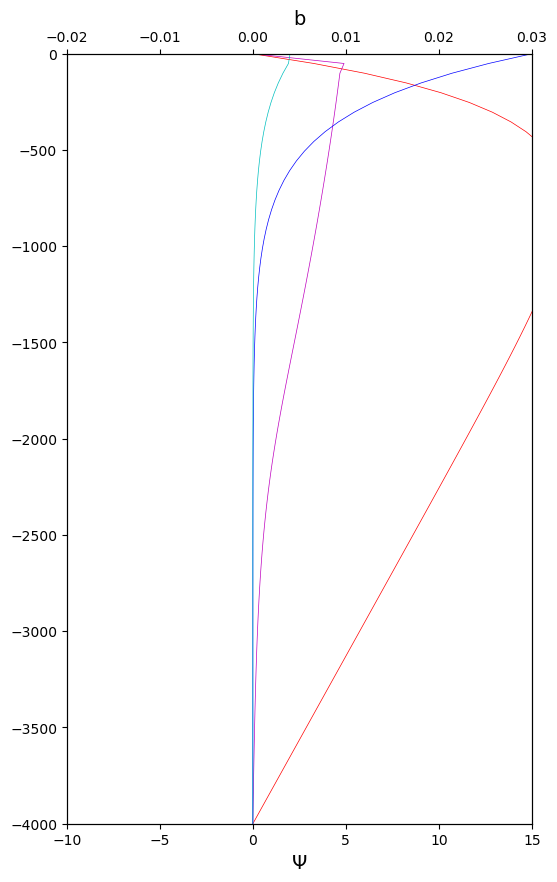

Text(0.5, 1.0, 'Depth-averaged Overturning')

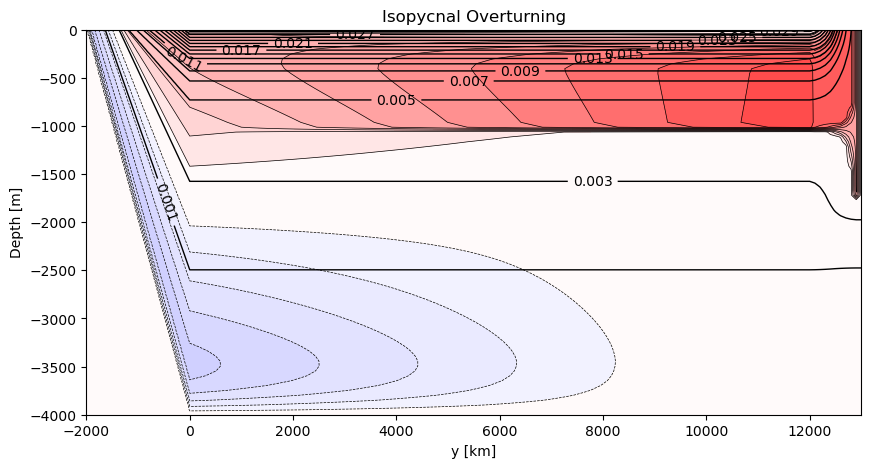

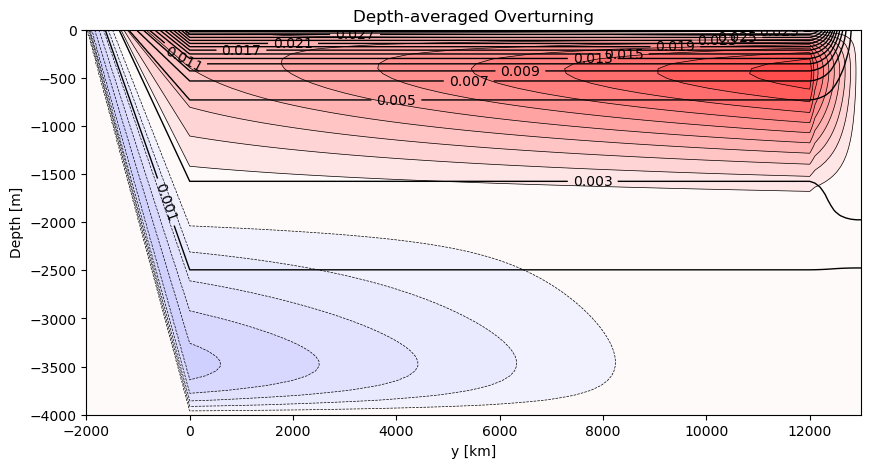

In [1]:
'''
This script shows an example of a "two column" model for the 
overturning circulation in a basin connected to a channel in the south.
The first column represents the basin, while the second column represents
the northern sinking region. The overtunning circulation is computed at
the northern end of the basin (at the interface to the northern sinking region)
and at the southern end of the basin (at the interface to the channel).
The parameters chosen here follow more or less the "control" experiment of Nikurashin
and Vallis (2012, JPO).
'''
from pymoc.modules import Psi_Thermwind, Psi_SO, Column
from pymoc.plotting import Interpolate_channel
import numpy as np
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d

# boundary conditions:
bs = 0.03
bs_north = 0.004
bmin = 0.0

# S.O. surface boundary conditions and grid:
l = 2.e6
y = np.asarray(np.linspace(0, l, 40))
#Although the model can emulate the effect of a meridionally varying wind-stress,
# that feature is in "beta" and we are here for simplicity using a constant
# wind-stress (approximately the average over the channel in NV12):
tau = 0.13
# from what I can infer, NV12 use an approximately quadratic surface temperature
# profile in the channel for their SAMBUCA simulations:
bs_SO = (bs-bmin) * (y / y[-1])**2 + bmin

A_basin = 6e13    #area of the basin
A_north = A_basin / 50.    #area of northern sinking region

# time-stepping parameters:
dt = 86400 * 30    # time-step for vert. adv. diff. calc.
MOC_up_iters = int(
    np.floor(2. * 360 * 86400 / dt)
)    # multiplier for MOC time-step (MOC is updated every MOC_up_iters time steps)
plot_iters = int(
    np.ceil(300 * 360 * 86400 / dt)
)    # plotting frequency (in iterations)
total_iters = int(
    np.ceil(3000 * 360 * 86400 / dt)
)    # total number of timesteps

kappa = 2e-5

# create vertical grid:
z = np.asarray(np.linspace(-4000, 0, 80))


# Initial conditions for buoyancy profile in the basin
def b_basin(z):
  return bs * np.exp(z / 300.)
def b_north(z):
  return bs_north * np.exp(z / 300.)


# create N.A. overturning model instance
AMOC = Psi_Thermwind(z=z, b1=b_basin, b2=b_north, f=1e-4)
# and solve for initial overturning streamfunction:
AMOC.solve()
# evaluate overturning in isopycnal space:
[Psi_iso_b, Psi_iso_n] = AMOC.Psibz()

# create S.O. overturning model instance
SO = Psi_SO(
    z=z,
    y=y,
    b=b_basin(z),
    bs=bs_SO,
    tau=tau,
    f=1e-4,
    L=5e6,
    KGM=1000.,
    c=0.1,
    bvp_with_Ek=True
)
SO.solve()

# create adv-diff column model instance for basin
basin = Column(z=z, kappa=kappa, Area=A_basin, b=b_basin, bs=bs, bbot=bmin)
# create adv-diff column model instance for basin
north = Column(z=z, kappa=kappa, Area=A_north, b=b_north, bs=bs_north, bbot=bmin)

# Create figure:
fig = plt.figure(figsize=(6, 10))
ax1 = fig.add_subplot(111)
ax2 = ax1.twiny()
plt.ylim((-4e3, 0))
ax1.set_xlim((-10, 15))
ax2.set_xlim((-0.02, 0.03))
ax1.set_xlabel('$\Psi$', fontsize=14)
ax2.set_xlabel('b', fontsize=14)

# Main time-stepping loop:
for ii in range(0, total_iters):
  # update buoyancy profile
  # using z-coordinate overturning:
  #wAb=(AMOC.Psi-SO.Psi)*1e6
  #wAN=-AMOC.Psi*1e6
  # using isopycnal overturning:
  wAb = (Psi_iso_b - SO.Psi) * 1e6
  wAN = -Psi_iso_n * 1e6
  basin.timestep(wA=wAb, dt=dt)
  north.timestep(wA=wAN, dt=dt, do_conv=True)
  if ii % MOC_up_iters == 0:
    # update overturning streamfunction (can be done less frequently)
    AMOC.update(b1=basin.b, b2=north.b)
    AMOC.solve()
    [Psi_iso_b, Psi_iso_n] = AMOC.Psibz()
    SO.update(b=basin.b)
    SO.solve()
  if ii % plot_iters == 0:
    # Plot current state:
    ax1.plot(AMOC.Psi, AMOC.z, linewidth=0.5, color='r')
    ax1.plot(SO.Psi, SO.z, linewidth=0.5, color='m')
    ax2.plot(basin.b, basin.z, linewidth=0.5, color='b')
    ax2.plot(north.b, north.z, linewidth=0.5, color='c')
    plt.pause(0.01)

# Plot final results over time-iteration plot:
ax1.plot(AMOC.Psi, AMOC.z, linewidth=2, color='r')
ax1.plot(SO.Psi, SO.z, linewidth=2, color='m')
ax1.plot(SO.Psi_Ek, SO.z, linewidth=1, color='m', linestyle='--')
ax1.plot(SO.Psi_GM, SO.z, linewidth=1, color='m', linestyle=':')
ax2.plot(basin.b, basin.z, linewidth=2, color='b')
ax2.plot(north.b, basin.z, linewidth=2, color='c')
ax1.plot(0. * AMOC.z, AMOC.z, linewidth=0.5, color='k')

#==============================================================================
# Everything below is just to make fancy 2D plots:
# This is mostly an exercise in interpolation, but useful to visualize solutions

# first interpolate buoyancy in channel along constant-slope isopycnals:
bint = Interpolate_channel(y=y, z=z, bs=bs_SO, bn=basin.b)
bsouth = bint.gridit()
# buoyancy in the basin is all the same:
ybasin = np.linspace(200., 12000., 60)
bbasin = np.tile(basin.b, (len(ybasin), 1))
# finally, interpolate buoyancy in the north:
ynorth = np.linspace(12100., 13000., 10)
bnorth = np.zeros((len(ynorth), len(z)))
for iz in range(len(z)):
  bnorth[:, iz] = interp1d([11900., 12000., 12900., 13000.], [
      basin.b[iz], basin.b[iz], north.b[iz], north.b[iz]
  ],
                           kind='quadratic')(ynorth)
# now stick it all together:
ynew = np.concatenate(((y-l) / 1e3, ybasin, ynorth))
bnew = np.concatenate((bsouth, bbasin, bnorth))

# Evaluate isopycnal overturning streamfunction at all latitudes:
psiarray_iso = np.zeros((len(ynew), len(z)))
psiarray_z = np.zeros((len(ynew), len(z)))
for iy in range(1, len(y)):
  # in the channel, interpolate SO.Psi onto local isopycnal depth:
  psiarray_iso[iy, :] = np.interp(bnew[iy, :], basin.b, SO.Psi)
  psiarray_z[iy, :] = psiarray_iso[iy, :]
for iy in range(len(y), len(y) + len(ybasin)):
  # in the basin, linearly interpolate between Psi_SO and Psi_AMOC:
  psiarray_iso[iy, :] = (
      ynew[iy] * AMOC.Psibz()[0] + (10000. - ynew[iy]) * SO.Psi
  ) / 10000.
  psiarray_z[iy, :
             ] = (ynew[iy] * AMOC.Psi + (10000. - ynew[iy]) * SO.Psi) / 10000.
for iy in range(len(y) + len(ybasin), len(ynew)):
  # in the north, interpolate AMOC.psib to local isopycnal depth:
  psiarray_iso[iy, :] = np.interp(bnew[iy, :], AMOC.bgrid, AMOC.Psib())
  psiarray_z[iy, :] = ((13000. - ynew[iy]) * AMOC.Psi) / 1000.
psiarray_iso[-1, :] = 0.

blevs = np.arange(0.001, 0.03, 0.002)
# Notice that the contour level for Psi is 0.5 SV for negative values
# and 1 SV for positive values. This appers to be what was used in NV2012.
plevs = np.concatenate((np.arange(-15., -0.4, 0.5), np.arange(1., 16., 1.)))

# plot isopycnal overturning:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111)
CS = ax1.contour(
    ynew,
    z,
    bnew.transpose(),
    levels=blevs,
    colors='k',
    linewidths=1.0,
    linestyles='solid'
)
ax1.clabel(CS, fontsize=10)
ax1.contour(
    ynew,
    z,
    psiarray_iso.transpose(),
    levels=plevs,
    colors='k',
    linewidths=0.5
)
CS = ax1.contourf(
    ynew,
    z,
    psiarray_iso.transpose(),
    levels=plevs,
    cmap=plt.cm.bwr,
    vmin=-15,
    vmax=15
)
#fig.colorbar(CS, ticks=plevs[0::2], orientation='vertical')
ax1.set_xlabel('y [km]')
ax1.set_ylabel('Depth [m]')
ax1.set_title('Isopycnal Overturning')

# plot z-coord. overturning:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111)
CS = ax1.contour(
    ynew,
    z,
    bnew.transpose(),
    levels=blevs,
    colors='k',
    linewidths=1.0,
    linestyles='solid'
)
ax1.clabel(CS, fontsize=10)
ax1.contour(
    ynew, z, psiarray_z.transpose(), levels=plevs, colors='k', linewidths=0.5
)
CS = ax1.contourf(
    ynew,
    z,
    psiarray_z.transpose(),
    levels=plevs,
    cmap=plt.cm.bwr,
    vmin=-15,
    vmax=15
)
#fig.colorbar(CS, ticks=plevs[0::2], orientation='vertical')
ax1.set_xlabel('y [km]')
ax1.set_ylabel('Depth [m]')
ax1.set_title('Depth-averaged Overturning')


In [2]:
bs_SO

array([0.00000000e+00, 1.97238659e-05, 7.88954635e-05, 1.77514793e-04,
       3.15581854e-04, 4.93096647e-04, 7.10059172e-04, 9.66469428e-04,
       1.26232742e-03, 1.59763314e-03, 1.97238659e-03, 2.38658777e-03,
       2.84023669e-03, 3.33333333e-03, 3.86587771e-03, 4.43786982e-03,
       5.04930966e-03, 5.70019724e-03, 6.39053254e-03, 7.12031558e-03,
       7.88954635e-03, 8.69822485e-03, 9.54635108e-03, 1.04339250e-02,
       1.13609467e-02, 1.23274162e-02, 1.33333333e-02, 1.43786982e-02,
       1.54635108e-02, 1.65877712e-02, 1.77514793e-02, 1.89546351e-02,
       2.01972387e-02, 2.14792899e-02, 2.28007890e-02, 2.41617357e-02,
       2.55621302e-02, 2.70019724e-02, 2.84812623e-02, 3.00000000e-02])